<a href="https://colab.research.google.com/github/filipeclduarte/SIMPAT-XV---M-todos-de-Previs-o-de-Mortalidade/blob/main/SIMPAT_XV_M%C3%A9todos_de_Previs%C3%A3o_de_Mortalidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Minicurso - Métodos de previsão de mortalidade

Autores:
- Filipe Coelho de Lima Duarte
- Cleo Decker Anacleto
- OIAtuarial

Inspirado: AI Tools for Actuaries (https://aitools4actuaries.com/)

### Objetivo do minicurso

- Compreender os fundamentos da modelagem preditiva aplicada à previsão da mortalidade.
- Aplicar modelos clássicos como ARIMA, ETS, Lee-Carter (LC) aos dados de mortalidade.
- Implementar modelos de deep learning (CNN, LSTM e Transformer) e aplicá-los em dados de mortalidade.
- Utilizar métodos de combinação de preditores.
- Avaliar a qualidade das previsões.

## Roteiro:

- Fundamentos
- Modelos estatísticos
- Modelos de Deep Learning
- Combinação de Preditores
- Avaliar os resultados

## 1. Fundamentos da modelagem preditiva aplicada à previsão de mortalidade

### 1.1 Por que projetar a mortalidade?

A previsão de mortalidade é usualmente o termo utilizado para representar o processo de prever as taxas de mortalidade humana. A taxa de mortalidade, denotada aqui como $m_{x,t}$ ou representa a taxa central de morte para a idade $x$ no ano $t$, ou seja, ela quantifica a
quantidade de óbitos para uma determinada idade $x$ em um período específico $t$.

Campo relevante que atrai diversos setores tais como:
* Demografia
* Atuarial (Seguros e previdência)
* Políticas públicas no geral (educação, seguridade social, saúde pública)


### 1.2 Previsão de séries temporais

A previsão de séries temporais consiste em modelar observações ordenadas no tempo para estimar valores futuros com base em padrões históricos, como tendência, sazonalidade, ciclos e flutuações aleatórias, sendo uma tarefa central em áreas como atuária, demografia, economia, finanças, saúde, energia, logística e monitoramento industrial.

É uma tarefa que pode ser formulada como o problema de inferir a distribuição condicional de uma variável aleatória indexada no tempo, $X_t$, a partir da informação disponível até o instante $t$, representada pelo conjunto $\mathcal{F}t$, com o objetivo de estimar $X{t+h}$ para horizontes $h \geq 1$.

Mais do que prever números, o objetivo é construir modelos capazes de capturar a dinâmica do processo gerador dos dados e produzir previsões úteis e confiáveis para apoiar a tomada de decisão em contextos reais.



#### 1.2.1 Projeção multi-step-ahead (extrapolação temporal de múltiplos passos à frente)

A previsão de vários passos à frente é mais difícil do que prever apenas o próximo instante, porque os erros tendem a se acumular ao longo do processo e a incerteza cresce à medida que aumenta o horizonte de previsão.

Na prática, isso significa usar os valores já observados para prever o próximo passo e, em seguida, utilizar essas previsões como entrada para estimar os instantes futuros seguintes.

<img width='800px' src='https://user-images.githubusercontent.com/18621301/51617459-47fe0d80-1efa-11e9-8a95-08af2660b085.png'>



### 1.3 Dados de mortalidade

Os dados de mortalidade possuem um padrão no formato 'J', como podemos ver no gráfico a seguir que mostra as taxas de morte da população mundial segundo "Global, regional, and national age-sex-specific mortality and life expectancy, 1950–2017: a systematic analysis for the Global Burden of Disease Study 2017". The Lancet 392 (10159): 1684-1735
DOI:10.1016/S0140-6736.

**Figura - "Padrão logarítmico global (taxa de mortalidade) por faixa etária para ambos os sexos combinados, por ano, 1950-2017. Cada linha representa o logaritmo das taxas globais de mortalidade por faixa etária para um determinado ano entre 1950 e 2017 e para ambos os sexos combinados. O recorte mostra uma visão mais detalhada das faixas etárias de 20 a 39 anos."**

<img widht='800px' src='https://i.imgur.com/QvxBDKo.png'>



### 1.3.1 Fonte de dados

Existem diversas fontes de dados de mortalidade que são construídos a partir de Censos demográficos, os quais servem de base para alimentar repositórios globais. Dentre esses repositórios podemos citar o Human Mortality Database (HMD) (https://www.mortality.org/), WHO Mortality Database (WHO) (https://www.who.int/data/data-collection-tools/who-mortality-database) e a World Population Prospects (WPP) da United Nations (ONU) (https://population.un.org/wpp/).

Neste curso vamos utilizar os dados da ONU.

- A principal fonte das Nações Unidas para dados de taxas de mortalidade é a base World Population Prospects (WPP), elaborada pela Population Division do Departamento de Assuntos Econômicos e Sociais da ONU.

- Essa base reúne estimativas históricas e projeções demográficas para países e territórios, incluindo indicadores como taxa bruta de mortalidade, mortalidade infantil, mortalidade de menores de 5 anos e expectativa de vida.

- Os indicadores divulgados pela ONU são construídos a partir da integração de diferentes fontes estatísticas nacionais e internacionais.

- A fonte preferencial é o registro civil e de estatísticas vitais de cada país, especialmente os registros de nascimentos e óbitos.
    
- Quando esses registros são incompletos ou indisponíveis, a ONU também utiliza censos demográficos, pesquisas domiciliares e outros levantamentos populacionais para produzir estimativas consistentes.
  
- Além da Population Division, a United Nations Statistics Division (UNSD) também disponibiliza estatísticas de mortalidade por meio do Demographic Yearbook.

- Assim, os dados de mortalidade das Nações Unidas resultam de um processo de compilação, padronização e estimação estatística, com o objetivo de garantir comparabilidade internacional e consistência temporal.



### 1.4 Métricas de erro

As métricas de erro de previsão são medidas usadas para avaliar o quão próximas as previsões estão dos valores reais
  observados. Elas são fundamentais para comparar modelos e verificar se um método produz previsões suficientemente precisas
  para o problema em estudo.

  As mais utilizadas são:

  - **MAE** (Mean Absolute Error): calcula a média dos erros absolutos. É simples de interpretar e indica, em média, o quanto a
    previsão se afasta do valor real.
  - **MSE** (Mean Squared Error): calcula a média dos erros ao quadrado. Penaliza mais fortemente erros grandes, sendo útil
    quando grandes desvios são especialmente indesejáveis.
  - **RMSE** (Root Mean Squared Error): corresponde à raiz quadrada do MSE. Mantém a mesma unidade da variável original, o que
    facilita a interpretação prática.
  - **MAPE** (Mean Absolute Percentage Error): expressa o erro médio em termos percentuais. É útil para comparar desempenho
    entre séries em escalas diferentes, mas pode ser problemático quando os valores reais são muito pequenos ou iguais a
    zero.
  - **sMAPE** (Symmetric Mean Absolute Percentage Error): é uma variação do MAPE que busca reduzir assimetrias na avaliação
    percentual do erro.
  - **MASE** (Mean Absolute Scaled Error): compara o erro do modelo com o erro de um método ingênuo de referência, sendo
    bastante útil para comparar séries diferentes.

  De forma geral, a escolha da métrica depende do contexto do problema.
  * Se a **interpretação direta for prioridade, o MAE** costuma ser uma boa opção;
  * se **erros grandes precisarem ser penalizados com mais rigor, RMSE e MSE** são mais adequados;
  * e, quando se deseja avaliar **erro relativo, métricas percentuais como MAPE ou sMAPE** podem ser consideradas com cautela.
  *  O **MASE deve ser escolhido quando se deseja uma métrica comparável entre séries temporais diferentes** e menos sensível aos
  problemas das métricas percentuais.

$$\mathrm{MAE} = \frac{1}{n}\sum_{t=1}^{n}|y_t - \hat{y}_t|$$

$$\mathrm{MSE} = \frac{1}{n}\sum_{t=1}^{n}(y_t - \hat{y}_t)^2$$

$$\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{t=1}^{n}(y_t - \hat{y}_t)^2}$$

$$\mathrm{MAPE} = \frac{100}{n}\sum_{t=1}^{n}\left|\frac{y_t - \hat{y}_t}{y_t}\right|$$

$$\mathrm{sMAPE} = \frac{100}{n}\sum_{t=1}^{n}\frac{|y_t - \hat{y}_t|}{\left(|y_t| + |\hat{y}_t|\right)/2}$$

$$\mathrm{MASE} = \frac{\frac{1}{n}\sum_{t=1}^{n}|y_t - \hat{y}_t|}{\frac{1}{T-1}\sum_{i=2}^{T}|y_i - y_{i-1}|}$$

  - $y_t$: valor observado no instante t
  - $\hat{y}_t$: valor previsto no instante t
  - $n$: número de previsões avaliadas
  - $T$: tamanho da série de treinamento


### 1.5 Etapas da modelagem

a. Coleta de dados

b. Pré-processamento de dados

c. Divisão dos dados Treinamento/Validação/Teste

d. Treinamento

e. Avaliação

f. Refinamento

g. Teste





### Coleta de dados

Vamos utilizar dados das nações unidas [UN Population Division Data Portal
](https://population.un.org/dataportal/home?df=692ecb60-91b1-4c9e-8e52-fb882385bd22)


Esses dados foram coletados e processados pela equipe do OIAtuarial (projeto extensão da UFPB). Os dados podem ser obtidos diretamente pela API que está disponível no web app: ...



In [1]:
# Configurar pacotes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import random

scaler = MinMaxScaler()

warnings.filterwarnings("ignore")

# Sementes de reprodutibilidade
np.random.seed(100)
torch.manual_seed(100)
random.seed(100)

In [2]:
# Instalar pacote para trabalhar com o Google Drive
!pip install gdown

In [3]:
# Carregar o pacote
import gdown

# O ID do arquivo contido no google drive
file_id = "1gZBwxkR5MbvLCrYc-82amWmWAODxN3yV"

# Nome do arquivo que vamos salvar no nosso diretório de trabalho
output_filename = "data.parquet"

# Realizando o download
gdown.download(id=file_id, output=output_filename, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1gZBwxkR5MbvLCrYc-82amWmWAODxN3yV
To: /content/data.parquet
100%|██████████| 27.3M/27.3M [00:00<00:00, 46.3MB/s]


'data.parquet'

In [4]:
# Utilizar o pandas para importar os dados
df = pd.read_parquet(output_filename)

# Apresentar as primeiras 5 linhas do df
display(df.head())

,Location,Iso3,Time,Age,AgeInt,nMx,nAx,nqx,lx,ndx,nLx,Sx,Tx,ex
0,Afghanistan,AFG,1950,0,1.0,0.347097,0.339756,0.282384,100000.000000,28238.377625,81355.783359,0.667156,2.813995e+06,28.139954
1,Afghanistan,AFG,1950,1,4.0,0.052227,1.356390,0.183565,71761.622375,13172.928163,252222.408093,0.856511,2.732640e+06,38.079401
2,Afghanistan,AFG,1950,5,5.0,0.010122,2.500000,0.049361,58588.694212,2892.003104,285713.463302,0.956631,2.480417e+06,42.336107
3,Afghanistan,AFG,1950,10,5.0,0.007553,2.500000,0.037066,55696.691108,2064.455392,273322.317061,0.957911,2.194704e+06,39.404562
4,Afghanistan,AFG,1950,15,5.0,0.010098,2.600874,0.049294,53632.235716,2643.751439,261818.486334,0.942513,1.921381e+06,35.825123


## Pré-processamento de dados

Precisamos filtrar os dados do Brasil, analisá-los e realizar algumas transformações.


In [5]:
# Note que importamos tábua de mortalidade abreviada
# Vamos filtrar o Brasil
df_br = df.query("Location == 'Brazil'")
df_br.head()

,Location,Iso3,Time,Age,AgeInt,nMx,nAx,nqx,lx,ndx,nLx,Sx,Tx,ex
41440,Brazil,BRA,1950,0,1.0,0.176597,0.339756,0.158156,100000.000000,15815.621261,89557.832499,0.822157,4.848084e+06,48.480845
41441,Brazil,BRA,1950,1,4.0,0.017903,1.356390,0.068374,84184.378739,5756.060372,321520.737600,0.945951,4.758527e+06,56.525055
41442,Brazil,BRA,1950,5,5.0,0.003375,2.500000,0.016736,78428.318367,1312.585695,388860.127598,0.984852,4.437006e+06,56.574029
41443,Brazil,BRA,1950,10,5.0,0.002725,2.500000,0.013534,77115.732672,1043.660853,382969.511229,0.984236,4.048146e+06,52.494422
41444,Brazil,BRA,1950,15,5.0,0.003836,2.629188,0.019007,76072.071819,1445.901373,376932.398498,0.977450,3.665176e+06,48.180314


**Observação sobre a tábua de mortalidade abreviada**:

* Essa é a estrutura de uma tábua de mortalidade abreviada, amplamente utilizada quando os dados não estão disponíveis em idade simples ou quando se busca maior estabilidade nas estimativas.

* Inicialmente, a primeira faixa etária corresponde ao intervalo de 0 a 1 ano, isto é, [0,1), sendo dedicada exclusivamente à mortalidade infantil, que possui dinâmica própria e, por isso, é tratada separadamente.

* Em seguida, aparece o grupo de 1 a 4 anos, representado como (1,4). Diferentemente dos demais, esse intervalo não é quinquenal, mas sim de quatro anos de amplitude, funcionando como uma transição entre a mortalidade infantil e os grupos etários padronizados.

* A partir dos 5 anos de idade, a estrutura passa a ser organizada em intervalos quinquenais, ou seja, grupos com cinco anos de amplitude:
(5,9), (10,14), (15,19), e assim sucessivamente.

* Por fim, há um grupo aberto no topo da distribuição, usualmente indicado como 90+, que agrega todos os indivíduos com 90 anos ou mais. Esse agrupamento ocorre porque, em idades muito avançadas, os dados tendem a ser mais escassos e sujeitos a maior variabilidade, justificando a consolidação em uma única faixa.

In [6]:
# Mostre os valores únicos para duas variáveis Age e AgeInt
print(f'Idades do intervalo inferior das Faixas etárias: {df_br.Age.unique()}')
print(f'Tamanho de intervalo das faixas etárias:         {df_br.AgeInt.unique()}')

Idades do intervalo inferior das Faixas etárias: [ 0  1  5 10 15 20 25 30 35 40 45 50 55 60 65 70 75 80 85 90]
Tamanho de intervalo das faixas etárias:         [ 1.  4.  5. nan]


In [7]:
# Ver a estrutura do dataframe
df_br.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1480 entries, 41440 to 42919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Location  1480 non-null   object 
 1   Iso3      1480 non-null   object 
 2   Time      1480 non-null   int32  
 3   Age       1480 non-null   int32  
 4   AgeInt    1406 non-null   float64
 5   nMx       1480 non-null   float64
 6   nAx       1480 non-null   float64
 7   nqx       1480 non-null   float64
 8   lx        1480 non-null   float64
 9   ndx       1480 non-null   float64
 10  nLx       1480 non-null   float64
 11  Sx        1480 non-null   float64
 12  Tx        1480 non-null   float64
 13  ex        1480 non-null   float64
dtypes: float64(10), int32(2), object(2)
memory usage: 161.9+ KB


In [8]:
# NaN ocorre porque não temos um tamanho de intervalo pois é aberto 90+
# Isso não é problema
# Mostrando
df_br[df_br['AgeInt'].isnull()]

,Location,Iso3,Time,Age,AgeInt,nMx,nAx,nqx,lx,ndx,nLx,Sx,Tx,ex
41459,Brazil,BRA,1950,90,NaN,0.377208,2.651060,1.0,1570.774852,1570.774852,4164.219005,0.0,4164.219005,2.651060
41479,Brazil,BRA,1951,90,NaN,0.374459,2.670517,1.0,1658.673964,1658.673964,4429.516844,0.0,4429.516844,2.670517
41499,Brazil,BRA,1952,90,NaN,0.371768,2.689852,1.0,1750.042223,1750.042223,4707.355094,0.0,4707.355094,2.689852
41519,Brazil,BRA,1953,90,NaN,0.371513,2.691693,1.0,1793.629176,1793.629176,4827.898559,0.0,4827.898559,2.691693
41539,Brazil,BRA,1954,90,NaN,0.371255,2.693567,1.0,1838.139821,1838.139821,4951.152572,0.0,4951.152572,2.693567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42839,Brazil,BRA,2019,90,NaN,0.232105,4.308401,1.0,17355.625962,17355.625962,74774.995762,0.0,74774.995762,4.308401
42859,Brazil,BRA,2020,90,NaN,0.292275,3.421430,1.0,13251.527803,13251.527803,45339.170568,0.0,45339.170568,3.421430
42879,Brazil,BRA,2021,90,NaN,0.251803,3.971362,1.0,13225.766262,13225.766262,52524.304857,0.0,52524.304857,3.971362
42899,Brazil,BRA,2022,90,NaN,0.288527,3.465880,1.0,14204.186689,14204.186689,49230.004939,0.0,49230.004939,3.465880


In [9]:
# Precisamos agora dos dados nMx que são as taxas de mortalidade
# Necessitamos também da variável Time (ano) e Age (idade que seria a faixa etária)
df2 = df_br[['Time', 'Age', 'nMx']].copy()
df2.head()

,Time,Age,nMx
41440,1950,0,0.176597
41441,1950,1,0.017903
41442,1950,5,0.003375
41443,1950,10,0.002725
41444,1950,15,0.003836


**Trasformação logarítmica das taxas**:

* Realiza-se a transformação das taxas de mortalidade ($_nM_x$) para a escala logarítmica, isto é, trabalha-se com ($\ln(_nM_x)$). Essa etapa é padrão em demografia e na modelagem de mortalidade por razões bem estabelecidas.

* Primeiramente, a transformação logarítmica **contribui para a estabilização da variância**. As taxas de mortalidade variam por várias ordens de magnitude ao longo das idades — são muito altas nos extremos (infância e idades avançadas) e bastante baixas em idades jovens-adultas. O log reduz essa disparidade, tornando os dados mais homogêneos do ponto de vista estatístico.

* Em segundo lugar, essa **transformação tende a linearizar as tendências temporais de declínio da mortalidade**. Como, em muitos contextos, a queda da mortalidade ao longo do tempo ocorre de forma aproximadamente exponencial, o uso do log converte esse padrão em algo próximo de linear, o que facilita a modelagem e a interpretação dos parâmetros.

* Por fim, ao trabalhar na escala logarítmica, **garante-se que as previsões, ao serem reconvertidas para a escala original, sejam sempre positivas** — uma propriedade essencial, já que taxas de mortalidade não podem assumir valores negativos.

* Por essas razões, modelos clássicos de mortalidade, como o modelo de Lee-Carter model, são formulados diretamente na escala $\ln(m_x)$.


In [10]:
# Vamos transformar nMx para a escala log.
df2['lnmx'] = np.log(df2['nMx'])
df2.head()

,Time,Age,nMx,lnmx
41440,1950,0,0.176597,-1.733886
41441,1950,1,0.017903,-4.022809
41442,1950,5,0.003375,-5.691221
41443,1950,10,0.002725,-5.905221
41444,1950,15,0.003836,-5.563333


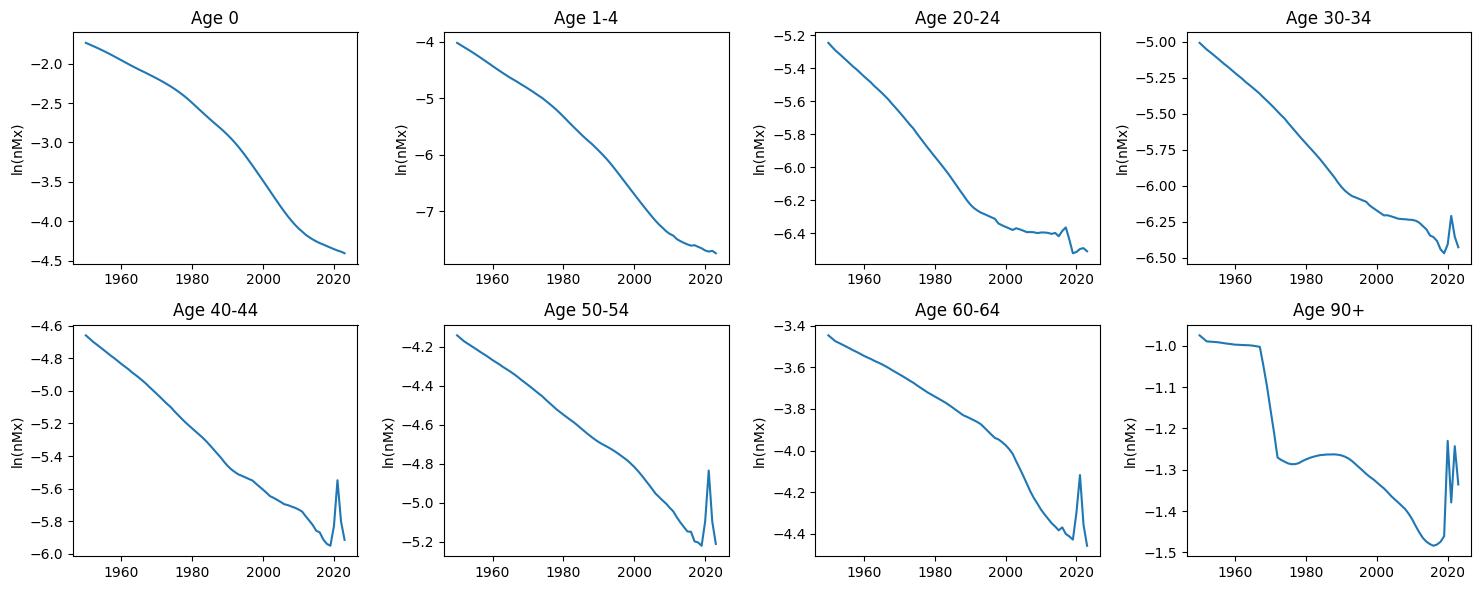

In [11]:
# Visualizar algumas idades evoluindo no tempo
fig, ax = plt.subplots(2, 4, figsize=(15, 6))

ax[0, 0].plot(df2.set_index("Time").query("Age == 0")['lnmx'])
ax[0, 0].set_ylabel('ln(nMx)')
ax[0, 0].set_title('Age 0')

ax[0, 1].plot(df2.set_index("Time").query("Age == 1")['lnmx'])
ax[0, 1].set_ylabel('ln(nMx)')
ax[0, 1].set_title('Age 1-4')

ax[0, 2].plot(df2.set_index("Time").query("Age == 20")['lnmx'])
ax[0, 2].set_ylabel('ln(nMx)')
ax[0, 2].set_title('Age 20-24')

ax[0, 3].plot(df2.set_index("Time").query("Age == 30")['lnmx'])
ax[0, 3].set_ylabel('ln(nMx)')
ax[0, 3].set_title('Age 30-34')

ax[1, 0].plot(df2.set_index("Time").query("Age == 40")['lnmx'])
ax[1, 0].set_ylabel('ln(nMx)')
ax[1, 0].set_title('Age 40-44')

ax[1, 1].plot(df2.set_index("Time").query("Age == 50")['lnmx'])
ax[1, 1].set_ylabel('ln(nMx)')
ax[1, 1].set_title('Age 50-54')

ax[1, 2].plot(df2.set_index("Time").query("Age == 60")['lnmx'])
ax[1, 2].set_ylabel('ln(nMx)')
ax[1, 2].set_title('Age 60-64')

ax[1, 3].plot(df2.set_index("Time").query("Age == 90")['lnmx'])
ax[1, 3].set_ylabel('ln(nMx)')
ax[1, 3].set_title('Age 90+')

plt.tight_layout()
plt.show()

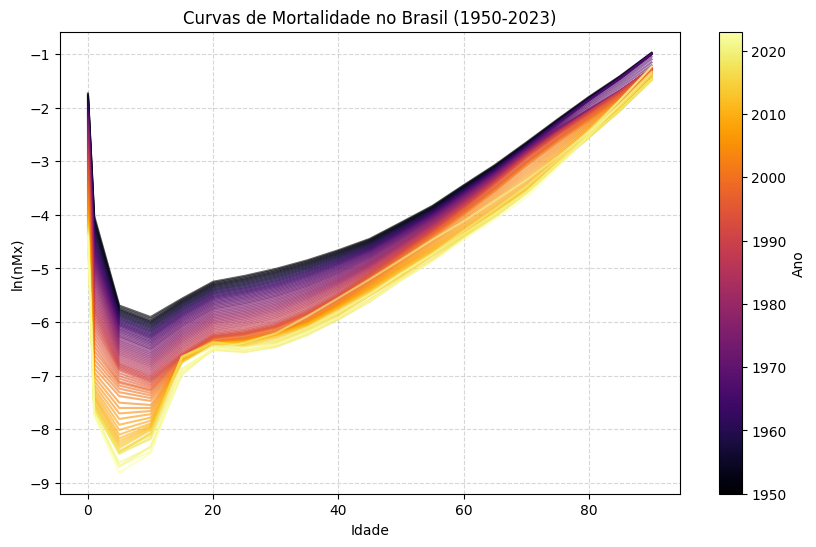

In [12]:
# Agora verificar a curva de mortalidade (múltiplas curvas com um degrade de cores (mosaico))
years = df2['Time'].unique()
colors = cm.get_cmap('inferno', len(years))

plt.figure(figsize=(10, 6))
for i, year in enumerate(sorted(years)):
    data_year = df2[df2['Time'] == year]
    plt.plot(data_year['Age'], data_year['lnmx'], color=colors(i), alpha=0.6)

plt.title('Curvas de Mortalidade no Brasil (1950-2023)')
plt.xlabel('Idade')
plt.ylabel('ln(nMx)')

# Adicionar uma barra de cores para indicar o tempo
sm = plt.cm.ScalarMappable(cmap='inferno', norm=plt.Normalize(vmin=min(years), vmax=max(years)))
sm._A = []

cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Ano')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


_ = '''
A linha sm._A = [] é um pequeno 'truque' necessário no Matplotlib por um motivo interno da biblioteca:
O ScalarMappable (sm): Ele é o objeto que guarda a relação entre os dados (Anos) e as cores (inferno).
A Barra de Cores (colorbar): Para criar a legenda lateral,
o Matplotlib precisa verificar se o objeto mapeável tem algum dado associado a ele para validar os limites da escala.
O Erro: Se você tentar criar um colorbar usando um ScalarMappable que não foi usado diretamente em um comando de plotagem (como scatter),
o Matplotlib pode lançar um erro dizendo que o objeto não tem um 'array' de dados definido.
Ao definir sm._A = [], você está inicializando manualmente esse array interno com uma lista vazia.
Isso 'engana' a função colorbar, permitindo que ela seja desenhada usando apenas
as informações de cmap e norm que definimos antes, sem travar o código.
'''

### Pivotar os dados

Na modelagem de mortalidade (como no modelo de Lee-Carter ou modelos de séries temporais para múltiplas idades), é fundamental organizar os dados em uma matriz de **Idades (linhas) × Anos (colunas)**.

Até agora, nosso DataFrame `df2` está no formato **longo** (cada observação é uma linha com Tempo, Idade e Valor). Ao pivotar:
1. Facilitamos a aplicação de Álgebra Linear (como SVD).
2. Conseguimos visualizar a série temporal de cada idade individualmente em colunas adjacentes.
3. O índice passa a ser a idade, o que é o padrão demográfico para tábuas de vida.

In [13]:
# Pivotando os dados: Age como índice, Time como colunas e lnmx como valores
df_pivot = df2.pivot(index='Age', columns='Time', values='lnmx')

print(f'Shape do pivot   : {df_pivot.shape}  (Ages × Years)')

# Exibir as primeiras idades e os primeiros anos para conferência
display(df_pivot.iloc[:5, :5])

Shape do pivot   : (20, 74)  (Ages × Years)


Time,1950,1951,1952,1953,1954
Age,,,,,
0,-1.733886,-1.753723,-1.773480,-1.793692,-1.814566
1,-4.022809,-4.061317,-4.099391,-4.137550,-4.176652
5,-5.691221,-5.722158,-5.753090,-5.772499,-5.793877
10,-5.905221,-5.940144,-5.975052,-5.995324,-6.017611
15,-5.563333,-5.586029,-5.608340,-5.626199,-5.645775


## Dividir os dados em treinamento/validação/teste

Na etapa de modelagem preditiva, é necessário dividir os dados em subconjuntos para treinar o modelo e avaliar seu desempenho de forma adequada.

Quando o **método não possui hiperparâmetros a serem ajustados, a divisão mais comum é entre treinamento e teste**: o conjunto de treinamento é usado para ajustar (treinar, estimar os parâmetros) o modelo, enquanto o conjunto de teste é reservado para a avaliação final, permitindo medir a capacidade de generalização em dados não vistos (também chamado de fora da amostra).

Em séries temporais, essa divisão deve respeitar a ordem cronológica dos dados, isto é, o modelo deve ser treinado com observações passadas etestado apenas em observações futuras.

Quando o **modelo possui hiperparâmetros**, é recomendável utilizar três subconjuntos: **treinamento, validação e teste**.

<img width='800x' src='https://i.sstatic.net/pXAfX.png'>

Em Machine Learning, a divisão dos dados é crucial para garantir que o modelo não apenas decore os dados (**overfitting**), mas aprenda padrões que possam ser aplicados a novos dados (**generalização**).

### Resumo da divisão dos dados:

1.  **Treinamento**: É o conjunto que o modelo usa para aprender os padrões.
2.  **Validação**: Usado para ajustar hiperparâmetros (como o número de camadas de uma rede neural) e evitar o overfitting durante o processo de treino.
3.  **Teste**: É o "exame final". São dados que o modelo nunca viu e servem para nos dar uma estimativa real da performance no mundo real.


No nosso caso, como queremos prever a mortalidade futura, vamos treinar o modelo com os anos iniciais e testar sua capacidade de prever os anos mais recentes da nossa série (ex: 2009-2023).



In [14]:
# Definindo os tamanhos das divisões (60/20/20)
n_years = df_pivot.shape[1]
train_end = int(n_years * 0.6)
val_end = int(n_years * 0.8)

# Divisão cronológica
train_data = df_pivot.iloc[:, :train_end]
val_data = df_pivot.iloc[:, train_end:val_end]
test_data = df_pivot.iloc[:, val_end:]

print(f'Anos de Treino:    {train_data.columns.min()} até {train_data.columns.max()} ({train_data.shape[1]} anos)')
print(f'Anos de Validação: {val_data.columns.min()} até {val_data.columns.max()} ({val_data.shape[1]} anos)')
print(f'Anos de Teste:     {test_data.columns.min()} até {test_data.columns.max()} ({test_data.shape[1]} anos)')

Anos de Treino:    1950 até 1993 (44 anos)
Anos de Validação: 1994 até 2008 (15 anos)
Anos de Teste:     2009 até 2023 (15 anos)


##4. Modelagem

## Lee-Carter

A base do modelo de Lee-Carter é a noção de que o nível geral de mortalidade é representado por um índice que varia no tempo (t = 1, ..., T) e pelo logaritmo da taxa de mortalidade em uma idade específica (x = 1, ..., X), o que reflete o padrão de mortalidade específico por idade.


$$log(m_{x,t}) = \alpha_x + \beta_xk_t + \epsilon_{x,t}$$


onde,
* $m_{x,t}$ é a taxa de mortalidade para a idade $x$ no tempo $t$;
* $\alpha_x$ é o componente específico por faixa etária do padrão de mortalidade por idade média, que mostra como as taxas de mortalidade variam entre as diferentes faixas etárias.
* $\beta_x$ mede a sensibilidade das taxas de mortalidade às variações ao longo do tempo para cada faixa etária. Ele mostra como as variações no nível geral de mortalidade afetam as taxas de mortalidade em diferentes idades no que diz respeito à dependência temporal.
* $k_t$ é um parâmetro variável no tempo que caracteriza o nível geral de mortalidade em um determinado ano ou momento. Ele é interpretado como uma medida do risco médio de mortalidade no momento t.
* $\epsilon_{x,t}$ ~ (0, σ2) é o termo de erro que leva em conta os fatores não observados e a variabilidade aleatória nas taxas de mortalidade para cada faixa etária x e momento t.


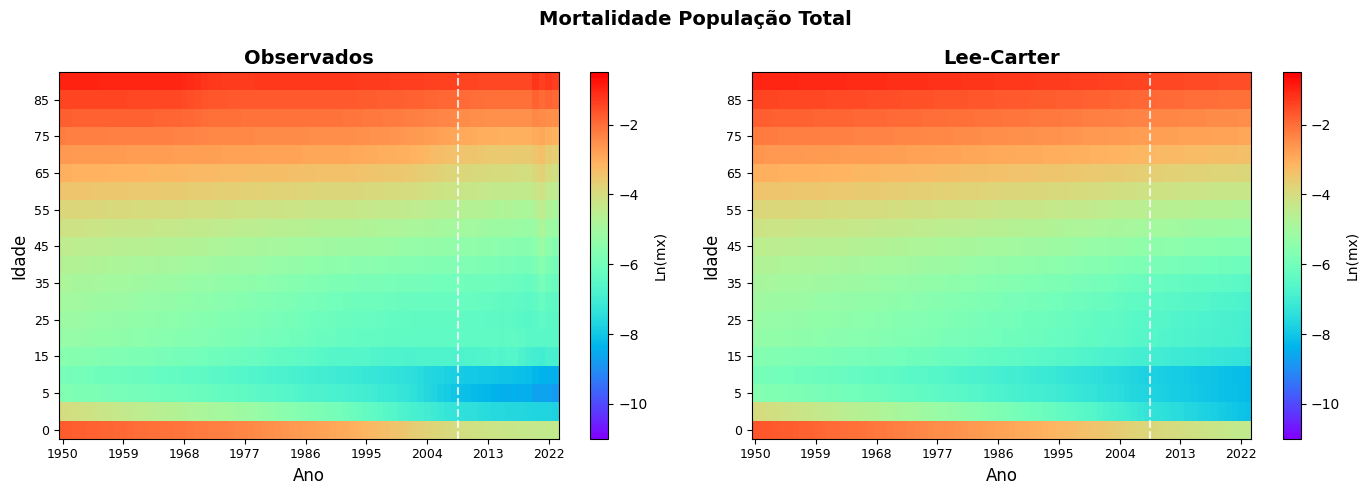

In [15]:
# ── 1. ax_lc  (média do log-mortalidade por idade, calculada no learn) ──────────
# treinamento + validação
learn = pd.concat([train_data, val_data], axis=1)
ax_lc = learn.mean(axis=1).values          # shape: (n_ages,)

# ── 2. Centraliza as taxas ────────────────────────────────────────────────────
learn_adj = learn.subtract(learn.mean(axis=1), axis=0)   # mx_adj = logmx - ax
rates_mat = learn_adj.values                              # shape: (n_ages, n_years_learn)

# ── 3. SVD — primeira componente principal (Lee-Carter) ──────────────────────
U, s, Vt = np.linalg.svd(rates_mat, full_matrices=False)
bx = U[:, 0] * s[0]
kt = Vt[0, :]

# ── 4. Normalização para identificabilidade ───────────────────────────────────
c1 = np.mean(kt)
c2 = np.sum(bx)
ax_lc = ax_lc + c1 * bx       # translada ax para centrar kt
bx = bx / c2            # normaliza bx
kt = (kt - c1) * c2     # centra kt

# ── 5. Previsão de kt  (random walk com drift) ────────────────────────────────
time_points = np.arange(len(kt))
slope       = np.polyfit(time_points, kt, 1)[0]
t_forecast  = test_data.shape[1]                              # nº de anos de teste
k_forecast  = kt[-1] + slope * np.arange(1, t_forecast + 1)

# ── 6. Fitted values e forecasts ──────────────────────────────────────────────
fitted_learn = ax_lc[:, np.newaxis] + np.outer(bx, kt)          # (n_ages, n_years_learn)
fitted_test  = ax_lc[:, np.newaxis] + np.outer(bx, k_forecast)  # (n_ages, n_years_test)

# ── 7. Monta df_pivot_lc  (Age × Year, todos os anos) ────────────────────────
years_learn = list(learn.columns)
years_test  = list(test_data.columns)
ages        = list(df_pivot.index)

df_lc_learn = pd.DataFrame(fitted_learn, index=ages, columns=years_learn)
df_lc_test  = pd.DataFrame(fitted_test,  index=ages, columns=years_test)
df_pivot_lc = pd.concat([df_lc_learn, df_lc_test], axis=1)   # Age × All years

# ── 8. Plot ───────────────────────────────────────────────────────────────────
def plot_mortality(mat, title, ax, z_min=-11, z_max=-0.5):
    im = ax.imshow(mat, aspect="auto", cmap="rainbow",
                   vmin=z_min, vmax=z_max, origin="lower")
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Ano", fontsize=12)
    ax.set_ylabel("Idade",  fontsize=12)

    # Ticks com anos e idades reais
    n_years = mat.shape[1]
    n_ages  = mat.shape[0]
    all_years = years_learn + years_test

    xtick_step = max(1, n_years  // 8)
    ytick_step = max(1, n_ages   // 8)

    ax.set_xticks(range(0, n_years, xtick_step))
    ax.set_xticklabels([str(all_years[i]) for i in range(0, n_years, xtick_step)], fontsize=9)
    ax.set_yticks(range(0, n_ages, ytick_step))
    ax.set_yticklabels([str(ages[i]) for i in range(0, n_ages, ytick_step)], fontsize=9)

    plt.colorbar(im, ax=ax, label="Ln(mx)")
    return im

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Mortalidade População Total", fontsize=14, fontweight="bold")

plot_mortality(df_pivot.values,    f"Observados",    axes[0])
plot_mortality(df_pivot_lc.values, f"Lee-Carter",  axes[1])

# Linha vertical marcando o corte learn/test
for ax in axes:
    cut = len(years_learn) - 0.5
    ax.axvline(cut, color="white", linewidth=1.5, linestyle="--", alpha=0.8)

plt.tight_layout()
plt.show()

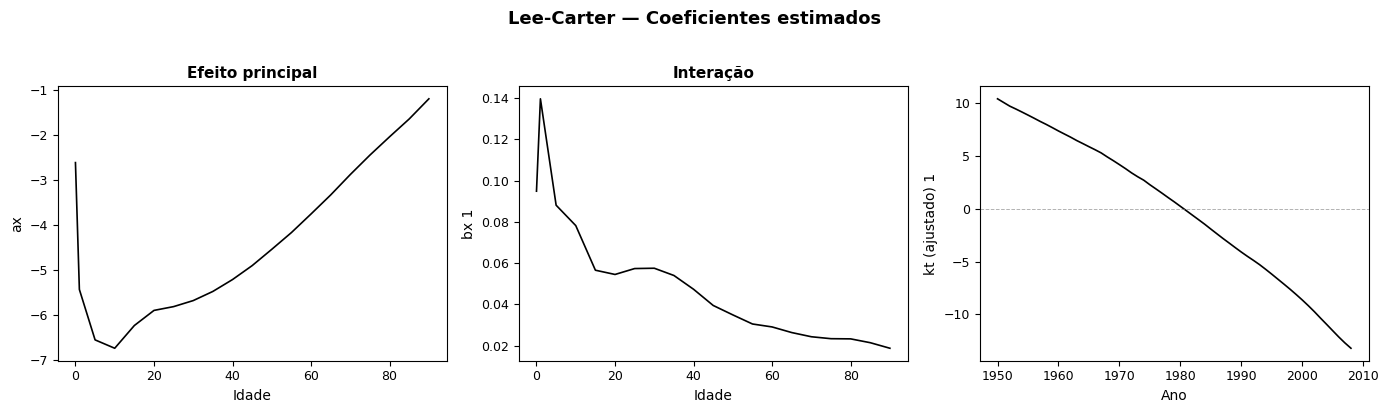

In [16]:
# plota os coeficientes ax, bx e kt do modelo Lee-Carter
# definição da função
def plot_lee_carter_coefs(ax_coef, bx_coef, kt_coef, ages, years_learn, title=None):
    """
    Plota os três coeficientes do modelo Lee-Carter em uma única linha.

    Parâmetros
    ----------
    ax_coef    : array (n_ages,)   – média do log da mortalidade por idade
    bx_coef    : array (n_ages,)   – sensibilidade de cada idade à tendência temporal
    kt_coef    : array (n_years,)  – índice de mortalidade ao longo do tempo
    ages       : list/array        – rótulos das idades
    years_learn: list/array        – anos do período de estimação
    title      : str, opcional     – título geral da figura
    """

    # Garante vetores 1-D independentemente do formato de entrada
    ages_arr  = np.asarray(ages).ravel()
    years_arr = np.asarray(years_learn).ravel()
    ax_arr    = np.asarray(ax_coef).ravel()
    bx_arr    = np.asarray(bx_coef).ravel()
    kt_arr    = np.asarray(kt_coef).ravel()

    # Verificação do número esperado de elementos em ax
    if ax_arr.shape[0] != ages_arr.shape[0]:
        raise ValueError(
            f"ax_coef (ax) possui número inesperado de elementos: {ax_arr.shape[0]}. "
            f"Esperado {ages_arr.shape[0]} elementos (número de idades). "
            "Verifique o cálculo ou a atribuição da variável 'ax'."
        )

    # Verificação do número esperado de elementos em bx
    if bx_arr.shape[0] != ages_arr.shape[0]:
        raise ValueError(
            f"bx_coef (bx) possui número inesperado de elementos: {bx_arr.shape[0]}. "
            f"Esperado {ages_arr.shape[0]} elementos (número de idades). "
            "Verifique o cálculo ou a atribuição da variável 'bx'."
        )

    fig, (p_ax, p_bx, p_kt) = plt.subplots(1, 3, figsize=(14, 4))

    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)

    # ── ax ─────────────────────────────────────────
    p_ax.plot(ages_arr, ax_arr, color="black", linewidth=1.2)
    p_ax.set_title("Efeito principal", fontsize=11, fontweight="bold")
    p_ax.set_xlabel("Idade", fontsize=10)
    p_ax.set_ylabel("ax", fontsize=10)
    p_ax.tick_params(labelsize=9)

    # ── bx ─────────────────────────────────────────
    p_bx.plot(ages_arr, bx_arr, color="black", linewidth=1.2)
    p_bx.set_title("Interação", fontsize=11, fontweight="bold")
    p_bx.set_xlabel("Idade", fontsize=10)
    p_bx.set_ylabel("bx 1", fontsize=10)
    p_bx.tick_params(labelsize=9)

    # ── kt ─────────────────────────────────────────
    p_kt.plot(years_arr, kt_arr, color="black", linewidth=1.2)
    p_kt.set_xlabel("Ano", fontsize=10)
    p_kt.set_ylabel("kt (ajustado) 1", fontsize=10)
    p_kt.tick_params(labelsize=9)
    p_kt.axhline(0, color="gray", linewidth=0.7, linestyle="--", alpha=0.6)

    plt.tight_layout()
    return fig


# Gera o gráfico
fig = plot_lee_carter_coefs(
    ax_coef     = ax_lc,      # variável 'ax' calculada no pipeline
    bx_coef     = bx,
    kt_coef     = kt,
    ages        = ages,
    years_learn = years_learn,
    title       = "Lee-Carter — Coeficientes estimados"
)

plt.show()

In [17]:
# Calcule os erros RMSE, MAE e sMAPE para nos dados de teste Lee-Carter

def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

# Valores reais (test_data) e previstos (df_lc_test)
y_true = test_data.values.flatten()
y_pred = df_lc_test.values.flatten()

rmse_lc = np.sqrt(mean_squared_error(y_true, y_pred))
mae_lc = mean_absolute_error(y_true, y_pred)
smape_lc = smape(y_true, y_pred)

print(f'Métricas Lee-Carter (Dados de Teste):')
print(f'RMSE:  {rmse_lc:.4f}')
print(f'MAE:   {mae_lc:.4f}')
print(f'sMAPE: {smape_lc:.4f}%')

Métricas Lee-Carter (Dados de Teste):
RMSE:  0.2340
MAE:   0.1905
sMAPE: 3.9005%


In [18]:
metrics_list = []

# Loop pelos anos do conjunto de teste
for year in years_test:
    y_true_year = test_data[year].values
    y_pred_year = df_lc_test[year].values

    rmse = np.sqrt(mean_squared_error(y_true_year, y_pred_year))
    mae = mean_absolute_error(y_true_year, y_pred_year)
    smape_val = smape(y_true_year, y_pred_year)

    metrics_list.append({
        'Ano': year,
        'RMSE': rmse,
        'MAE': mae,
        'sMAPE (%)': smape_val
    })

# Criar DataFrame com os resultados
df_metrics_years = pd.DataFrame(metrics_list)
display(df_metrics_years)

,Ano,RMSE,MAE,sMAPE (%)
0,2009,0.167434,0.139311,2.899784
1,2010,0.184776,0.152873,3.178098
2,2011,0.197786,0.163376,3.382710
3,2012,0.207931,0.170643,3.528010
4,2013,0.216195,0.177634,3.659294
5,2014,0.224178,0.183454,3.751373
6,2015,0.230202,0.188450,3.820325
7,2016,0.232955,0.188287,3.752988
8,2017,0.239713,0.195402,3.885521
9,2018,0.223944,0.185582,3.704233


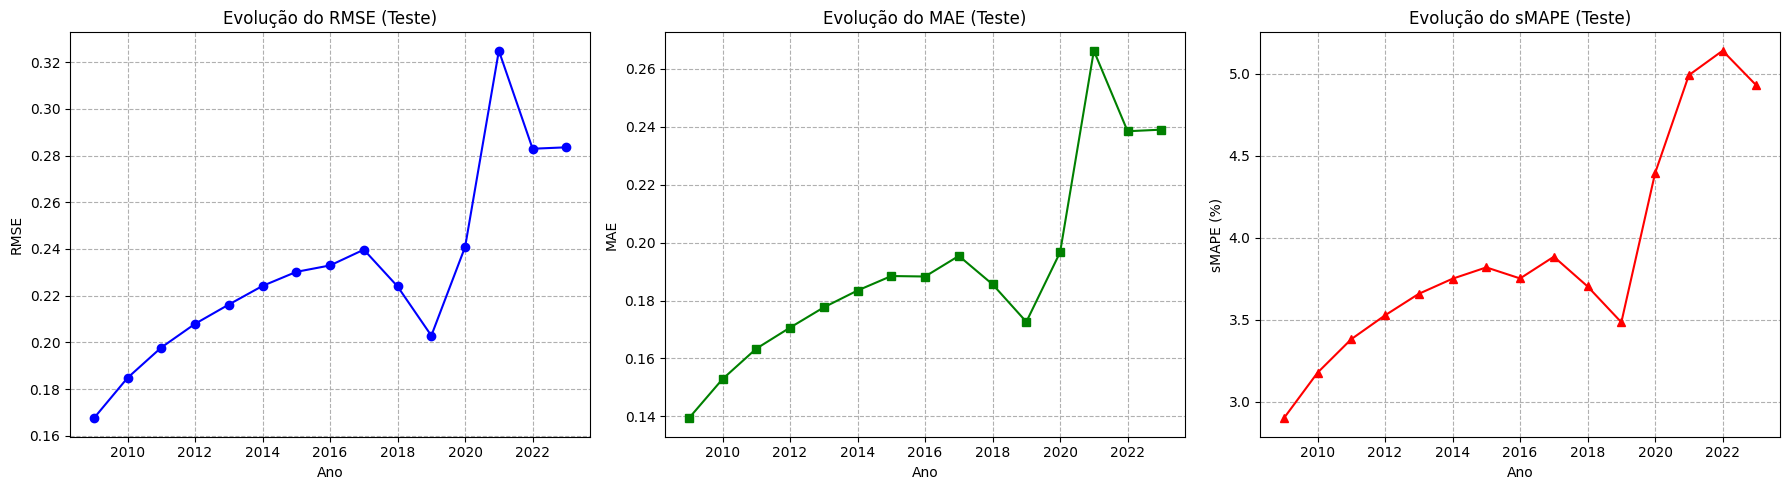

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico RMSE
axes[0].plot(df_metrics_years['Ano'], df_metrics_years['RMSE'], marker='o', color='blue')
axes[0].set_title('Evolução do RMSE (Teste)')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('RMSE')
axes[0].grid(True, linestyle='--')

# Gráfico MAE
axes[1].plot(df_metrics_years['Ano'], df_metrics_years['MAE'], marker='s', color='green')
axes[1].set_title('Evolução do MAE (Teste)')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('MAE')
axes[1].grid(True, linestyle='--')

# Gráfico sMAPE
axes[2].plot(df_metrics_years['Ano'], df_metrics_years['sMAPE (%)'], marker='^', color='red')
axes[2].set_title('Evolução do sMAPE (Teste)')
axes[2].set_xlabel('Ano')
axes[2].set_ylabel('sMAPE (%)')
axes[2].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

## ARIMA


• O modelo ARIMA é um dos métodos mais clássicos e importantes para previsão de séries temporais. Seu nome vem de
  AutoRegressive Integrated Moving Average, isto é, um modelo que combina três ideias principais:
  - a parte autorregressiva
  (AR), em que os valores passados da própria série ajudam a explicar o valor atual;
  - a parte de integração (I), que
  representa o número de diferenciações aplicadas para tornar a série mais estável;
  - e a parte de média móvel (MA), que
  utiliza a dependência entre o valor atual e erros aleatórios observados em instantes anteriores. De forma geral, o ARIMA
  busca capturar a estrutura temporal da série com base em sua própria dinâmica passada.

• Os parâmetros do modelo são geralmente representados por ARIMA(p,d,q). O parâmetro p indica a ordem da parte
  autorregressiva, ou seja, quantos valores passados da série são usados no modelo. O parâmetro d indica o número de
  diferenciações necessárias para reduzir tendência e tornar a série aproximadamente estacionária. Já o parâmetro q
  representa a ordem da parte de média móvel, associada aos erros passados incorporados à modelagem. Assim, ajustar um
  modelo ARIMA significa definir adequadamente esses três componentes para representar o comportamento da série temporal.

• Na prática, uma das maiores dificuldades ao usar ARIMA está justamente na escolha dos valores de p, d e q. Essa escolha
  pode ser feita com base em análise estatística, inspeção da autocorrelação e autocorrelação parcial, além de critérios de
  informação. Para simplificar esse processo, utiliza-se o AUTO-ARIMA, que automatiza a busca pela melhor combinação de
  parâmetros dentro de um conjunto de possibilidades predefinidas. Em vez de testar manualmente vários modelos, o algoritmo
  avalia diferentes combinações e seleciona aquela que apresenta melhor desempenho segundo critérios como AIC, AICc ou BIC.

• Portanto, o ARIMA é um modelo estatístico bastante útil quando a série apresenta dependência temporal bem definida e
  quando se deseja uma abordagem interpretável e consolidada na literatura. O auto-ARIMA, por sua vez, é uma alternativa
  prática para automatizar a etapa de seleção do modelo, tornando o processo mais ágil e acessível, especialmente em
  aplicações introdutórias e comparativas.


In [20]:
# Instalar e carregar pacote para trabalhar com ARIMA
!pip install pmdarima

from pmdarima import auto_arima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 45.3 MB/s eta 0:00:00


In [21]:
# Criamos duas matrizes vazias para armazenar os resultados do ARIMA.
# A primeira guardará os valores ajustados (fitted) no período de treino,
# e a segunda armazenará as previsões para o período de teste.
arima_fitted = np.empty((learn.shape[0], len(years_learn)))
arima_forecast = np.empty((test_data.shape[0], len(years_test)))

# Itera por cada idade presente no DataFrame de treino (20 grupos etários)
for i, age in enumerate(learn.index):
    series = learn.loc[age]

    # Ajusta um modelo auto_arima à série temporal da idade correspondente
    model = auto_arima(series,
                       seasonal=False,
                       stepwise=True,
                       suppress_warnings=True,
                       error_action='ignore')

    # Obtém os valores ajustados (fitted values) para o período 1950–2008
    fitted_values = model.predict_in_sample()
    arima_fitted[i, :] = fitted_values.values
    # arima_fitted_list.append(fitted_values)

    # Gera previsões para o período de teste (2009–2023)
    n_periods = len(years_test)
    forecast = model.predict(n_periods=n_periods)
    arima_forecast[i, :] = forecast.values
    # arima_forecast_list.append(forecast)

# Cria DataFrames a partir das matrizes de resultados
df_arima_train = pd.DataFrame(arima_fitted, index=learn.index, columns=years_learn)
df_arima_test = pd.DataFrame(arima_forecast, index=learn.index, columns=years_test)

# Concatena treino e teste para reconstruir a superfície completa de mortalidade
df_pivot_arima = pd.concat([df_arima_train, df_arima_test], axis=1)

print('Treinamento e previsão com Auto ARIMA concluídos para todos os grupos etários.')
display(df_pivot_arima.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa

Treinamento e previsão com Auto ARIMA concluídos para todos os grupos etários.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Age,,,,,,,,,,,,,,,,,,,,,
0,0.0,-2.600830,-1.773559,-1.793164,-1.814244,-1.836087,-1.859179,-1.882276,-1.905845,-1.930472,...,-4.240603,-4.271123,-4.299704,-4.326722,-4.352507,-4.377344,-4.401469,-4.425077,-4.448323,-4.471332
1,0.0,-6.034213,-4.099825,-4.137217,-4.175605,-4.216114,-4.258763,-4.301401,-4.344355,-4.388695,...,-7.522113,-7.551443,-7.583135,-7.618187,-7.656865,-7.698767,-7.743005,-7.788431,-7.833879,-7.878364
5,0.0,-8.536831,-5.753096,-5.784024,-5.794565,-5.814800,-5.837351,-5.858965,-5.881511,-5.899517,...,-8.617845,-8.718554,-8.819262,-8.919970,-9.020678,-9.121387,-9.222095,-9.322803,-9.423512,-9.524220
10,0.0,-8.857831,-5.975068,-6.009965,-6.020595,-6.039210,-6.062639,-6.085686,-6.110183,-6.129294,...,-8.192199,-8.250918,-8.309635,-8.368352,-8.427070,-8.485787,-8.544505,-8.603223,-8.661940,-8.720658
15,0.0,-8.344999,-5.608725,-5.630652,-5.644058,-5.665350,-5.685303,-5.705653,-5.727366,-5.742957,...,-6.758368,-6.761805,-6.765241,-6.768677,-6.772113,-6.775550,-6.778986,-6.782422,-6.785858,-6.789294


## Visualizar Superfícies de Mortalidade

Criar um gráfico comparativo de mapas de calor entre as taxas de mortalidade observadas e as estimadas pelo modelo Auto ARIMA.


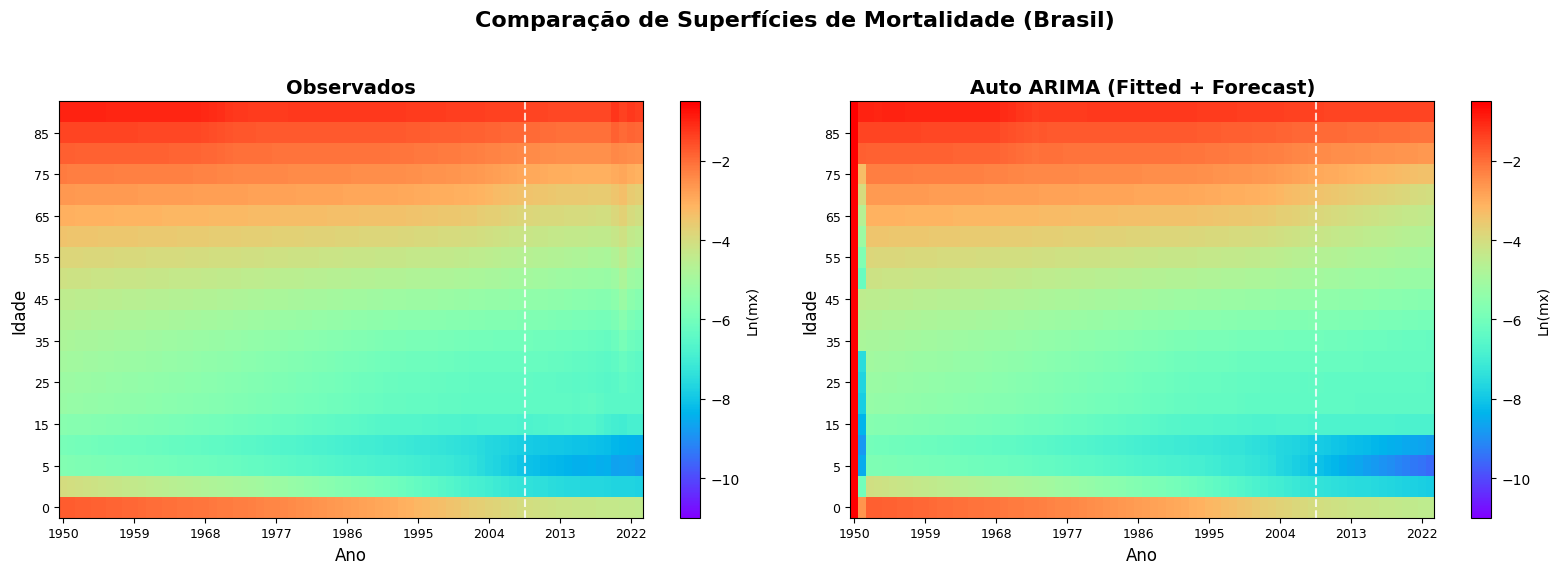

In [22]:
# Definindo a função
def plot_comparison(mat, title, ax, ages, years, cut_year_idx, z_min=-11, z_max=-0.5):
    im = ax.imshow(mat, aspect='auto', cmap='rainbow', vmin=z_min, vmax=z_max, origin='lower')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Ano', fontsize=12)
    ax.set_ylabel('Idade', fontsize=12)

    n_years = mat.shape[1]
    n_ages = mat.shape[0]
    xtick_step = max(1, n_years // 8)
    ytick_step = max(1, n_ages // 8)

    ax.set_xticks(range(0, n_years, xtick_step))
    ax.set_xticklabels([str(years[i]) for i in range(0, n_years, xtick_step)], fontsize=9)
    ax.set_yticks(range(0, n_ages, ytick_step))
    ax.set_yticklabels([str(ages[i]) for i in range(0, n_ages, ytick_step)], fontsize=9)

    # Adicionar linha vertical que separa treinamento/teste
    ax.axvline(cut_year_idx - 0.5, color='white', linewidth=1.5, linestyle='--', alpha=0.8)

    plt.colorbar(im, ax=ax, label='Ln(mx)')
    return im

# Preparar dados e rótulos
all_years = list(df_pivot.columns)
ages_list = list(df_pivot.index)
cut_idx = len(years_learn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparação de Superfícies de Mortalidade (Brasil)', fontsize=16, fontweight='bold')

# Plot Dados Reais
plot_comparison(df_pivot.values, 'Observados', axes[0], ages_list, all_years, cut_idx)

# Plot Auto ARIMA
plot_comparison(df_pivot_arima.values, 'Auto ARIMA (Fitted + Forecast)', axes[1], ages_list, all_years, cut_idx)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Calcular Métricas de Erro ARIMA

Calcular as métricas globais e anuais (RMSE, MAE e sMAPE) para o modelo Auto ARIMA no conjunto de teste.


In [23]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

# 1. Métricas Globais (Flattened data)
y_true_all = test_data.values.flatten()
y_pred_all = df_arima_test.values.flatten()

rmse_arima = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
mae_arima = mean_absolute_error(y_true_all, y_pred_all)
smape_arima = smape(y_true_all, y_pred_all)

print(f'Métricas Auto ARIMA Globais (Dados de Teste):')
print(f'RMSE:  {rmse_arima:.4f}')
print(f'MAE:   {mae_arima:.4f}')
print(f'sMAPE: {smape_arima:.4f}%\n')

# 2. Métricas por ano
arima_metrics_list = []

for year in years_test:
    y_true_year = test_data[year].values
    y_pred_year = df_arima_test[year].values

    rmse = np.sqrt(mean_squared_error(y_true_year, y_pred_year))
    mae = mean_absolute_error(y_true_year, y_pred_year)
    smape_val = smape(y_true_year, y_pred_year)

    arima_metrics_list.append({
        'Ano': year,
        'RMSE': rmse,
        'MAE': mae,
        'sMAPE (%)': smape_val
    })

# 3. DataFrame
df_metrics_arima = pd.DataFrame(arima_metrics_list)
display(df_metrics_arima)

Métricas Auto ARIMA Globais (Dados de Teste):
RMSE:  0.1757
MAE:   0.1071
sMAPE: 2.3428%



,Ano,RMSE,MAE,sMAPE (%)
0,2009,0.005105,0.004018,0.093961
1,2010,0.015646,0.010688,0.244310
2,2011,0.031614,0.021001,0.480677
3,2012,0.051038,0.035101,0.771281
4,2013,0.069630,0.048766,1.050945
5,2014,0.089739,0.063293,1.330064
6,2015,0.098501,0.072528,1.517826
7,2016,0.132541,0.091465,1.877963
8,2017,0.157700,0.107852,2.119940
9,2018,0.173831,0.117405,2.277935


## Gráficos de Evolução do Erro


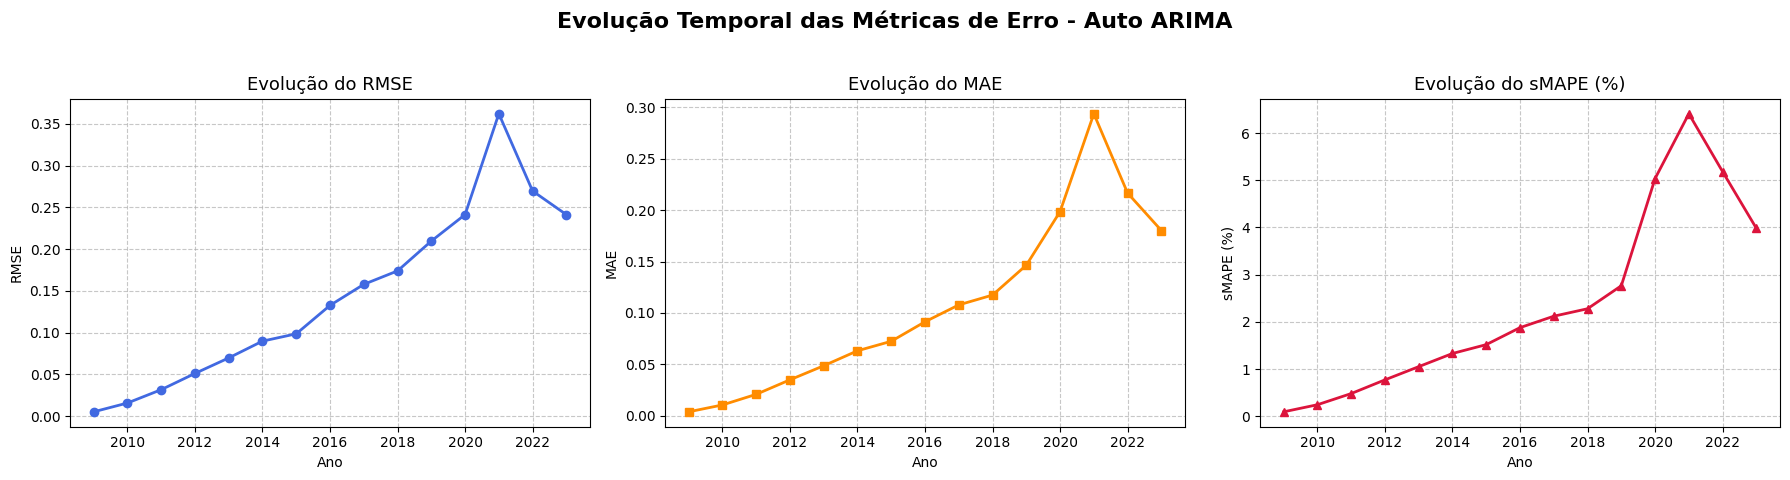

In [24]:
# Criando figura com 1 linha e 3 colunas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Evolução Temporal das Métricas de Erro - Auto ARIMA', fontsize=16, fontweight='bold')

# 1. Plot RMSE
axes[0].plot(df_metrics_arima['Ano'], df_metrics_arima['RMSE'], marker='o', color='royalblue', linestyle='-', linewidth=2)
axes[0].set_title('Evolução do RMSE', fontsize=13)
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('RMSE')
axes[0].grid(True, linestyle='--', alpha=0.7)

# 2. Plot MAE
axes[1].plot(df_metrics_arima['Ano'], df_metrics_arima['MAE'], marker='s', color='darkorange', linestyle='-', linewidth=2)
axes[1].set_title('Evolução do MAE', fontsize=13)
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('MAE')
axes[1].grid(True, linestyle='--', alpha=0.7)

# 3. Plot sMAPE (%)
axes[2].plot(df_metrics_arima['Ano'], df_metrics_arima['sMAPE (%)'], marker='^', color='crimson', linestyle='-', linewidth=2)
axes[2].set_title('Evolução do sMAPE (%)', fontsize=13)
axes[2].set_xlabel('Ano')
axes[2].set_ylabel('sMAPE (%)')
axes[2].grid(True, linestyle='--', alpha=0.7)

# Ajustando layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### Tabela Comparativa

Gerar uma tabela consolidada comparando as métricas globais do modelo Lee-Carter e do Auto ARIMA para determinar qual apresentou melhor performance para os dados do Brasil.


In [25]:
# Criar o DataFrame comparativo consolidando as métricas globais
data_comparativo = {
    'Modelo': ['Lee-Carter', 'Auto ARIMA'],
    'RMSE': [rmse_lc, rmse_arima],
    'MAE': [mae_lc, mae_arima],
    'sMAPE (%)': [smape_lc, smape_arima]
}

df_comparativo = pd.DataFrame(data_comparativo)

# Exibir a tabela consolidada
print('Comparação de Performance: Lee-Carter vs Auto ARIMA (Conjunto de Teste)')
display(df_comparativo)

Comparação de Performance: Lee-Carter vs Auto ARIMA (Conjunto de Teste)


,Modelo,RMSE,MAE,sMAPE (%)
0,Lee-Carter,0.234045,0.190532,3.900534
1,Auto ARIMA,0.175701,0.107137,2.342789


## ETS

• O modelo ETS é uma abordagem clássica de previsão de séries temporais baseada em suavização exponencial. A sigla ETS vem
  de Error, Trend and Seasonality, indicando que o modelo é definido pela forma como representa três componentes centrais da
  série: o erro, a tendência e a sazonalidade. Em termos práticos, o ETS é especialmente útil quando a série apresenta
  padrões estruturais claros ao longo do tempo, como crescimento, decrescimento ou comportamento sazonal recorrente, e
  quando se deseja uma modelagem flexível, mas ainda interpretável.

• Uma característica importante do ETS é que ele não corresponde a um único modelo, mas a uma família de modelos. Cada
  especificação combina diferentes formas para os componentes de erro, tendência e sazonalidade, que podem ser, por exemplo,
  aditivos, multiplicativos ou ausentes, dependendo do comportamento observado na série. Dessa forma, o modelo é capaz de se
  adaptar a diferentes perfis de dados. Por exemplo, uma série com variação sazonal aproximadamente constante pode ser
  melhor descrita por uma sazonalidade aditiva, enquanto uma série em que a amplitude sazonal cresce com o nível pode exigir
  uma componente multiplicativa.

• Na prática, a escolha manual da melhor estrutura ETS pode ser trabalhosa, pois envolve comparar várias combinações
  possíveis entre erro, tendência e sazonalidade. Por isso, utiliza-se frequentemente um algoritmo de seleção automática,
  que testa diferentes especificações da família ETS e escolhe aquela que melhor se ajusta aos dados com base em critérios
  de informação, como AIC, AICc ou BIC. Esse procedimento automático é amplamente utilizado em softwares estatísticos e
  bibliotecas de previsão, permitindo selecionar de forma sistemática o modelo mais adequado sem depender exclusivamente de
  inspeção manual.

• Assim, o modelo ETS é uma alternativa bastante eficiente para séries temporais com estrutura de nível, tendência e
  sazonalidade bem definida. Já o procedimento automático de busca do melhor modelo torna essa abordagem ainda mais prática,
  pois reduz o esforço de especificação e facilita a aplicação em contextos didáticos, comparativos e operacionais.


In [26]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Inicializar os arrays
ets_fitted = np.empty((learn.shape[0], len(years_learn)))
ets_forecast = np.empty((test_data.shape[0], len(years_test)))

# Modelagem para cada idade
for i, age in enumerate(learn.index):
    series = learn.loc[age]

    # Iniciar modelo
    # trend='add' é utilizada para capturar o declínio temporal da mortalidade ao longo dos anos
    model = ExponentialSmoothing(series, trend='add', seasonal=None, initialization_method='estimated')
    model_fit = model.fit()

    #  fitted values (1950-2008)
    ets_fitted[i, :] = model_fit.fittedvalues.values

    # forecasts (2009-2023)
    n_periods = len(years_test)
    forecast = model_fit.forecast(n_periods)
    ets_forecast[i, :] = forecast.values

# df dos resultados
df_ets_train = pd.DataFrame(ets_fitted, index=learn.index, columns=years_learn)
df_ets_test = pd.DataFrame(ets_forecast, index=learn.index, columns=years_test)

# concatenar para gerar toda a superfice de mortlalidade
df_pivot_ets = pd.concat([df_ets_train, df_ets_test], axis=1)

print('ETS training and forecasting completed for all age groups.')
display(df_pivot_ets.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
 

ETS training and forecasting completed for all age groups.


,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Age,,,,,,,,,,,,,,,,,,,,,
0,-1.733887,-1.753723,-1.773559,-1.793236,-1.813904,-1.835441,-1.858242,-1.881491,-1.905249,-1.929864,...,-4.322868,-4.377795,-4.432722,-4.487649,-4.542576,-4.597503,-4.652430,-4.707357,-4.762284,-4.817211
1,-4.022809,-4.061317,-4.099825,-4.137465,-4.175709,-4.215753,-4.257793,-4.300247,-4.343346,-4.387922,...,-7.640369,-7.698556,-7.756744,-7.814931,-7.873119,-7.931306,-7.989494,-8.047681,-8.105869,-8.164056
5,-5.691453,-5.722445,-5.753145,-5.784012,-5.794666,-5.814497,-5.837101,-5.858979,-5.881534,-5.899555,...,-8.618089,-8.718788,-8.819486,-8.920185,-9.020884,-9.121582,-9.222281,-9.322980,-9.423678,-9.524377
10,-5.905664,-5.939487,-5.974788,-6.009916,-6.021017,-6.039951,-6.062368,-6.085562,-6.110129,-6.129335,...,-8.192875,-8.251716,-8.310556,-8.369396,-8.428236,-8.487076,-8.545916,-8.604756,-8.663596,-8.722436
15,-5.563458,-5.585996,-5.608706,-5.630746,-5.645159,-5.664809,-5.685174,-5.705610,-5.727186,-5.743645,...,-6.761692,-6.765678,-6.769663,-6.773649,-6.777635,-6.781620,-6.785606,-6.789592,-6.793578,-6.797563


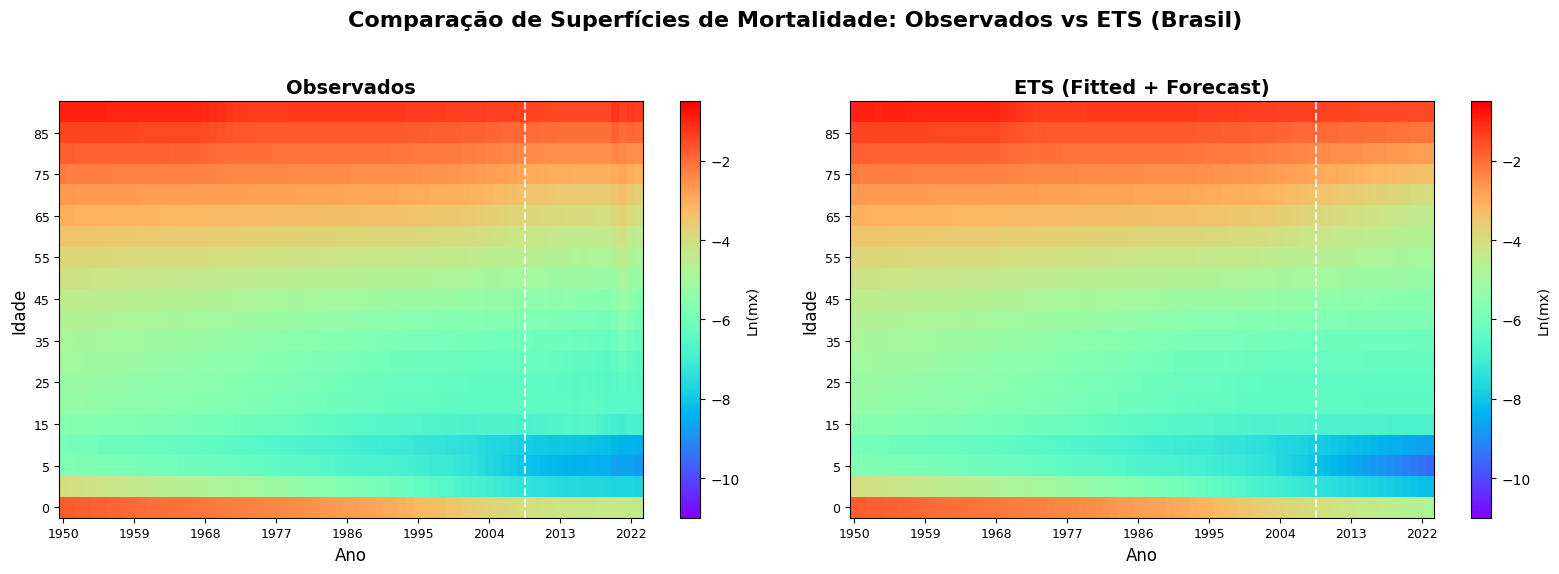

In [27]:

# Figura
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparação de Superfícies de Mortalidade: Observados vs ETS (Brasil)', fontsize=16, fontweight='bold')

# Plot Observed
plot_comparison(df_pivot.values, 'Observados', axes[0], ages_list, all_years, cut_idx)

# Plot ETS  (Fitted 1950-2008 + Forecast 2009-2023)
plot_comparison(df_pivot_ets.values, 'ETS (Fitted + Forecast)', axes[1], ages_list, all_years, cut_idx)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### ETS - erros



Métricas ETS Globais (Dados de Teste):
RMSE:  0.1917
MAE:   0.1252
sMAPE: 2.7268%



,Ano,RMSE,MAE,sMAPE (%)
0,2009,0.004875,0.003691,0.082868
1,2010,0.015847,0.010699,0.228187
2,2011,0.032998,0.022795,0.476190
3,2012,0.052219,0.037298,0.762106
4,2013,0.072229,0.053264,1.065133
5,2014,0.094345,0.071096,1.396075
6,2015,0.106672,0.084979,1.659775
7,2016,0.142678,0.108947,2.109528
8,2017,0.173315,0.131584,2.449748
9,2018,0.193548,0.147139,2.781152


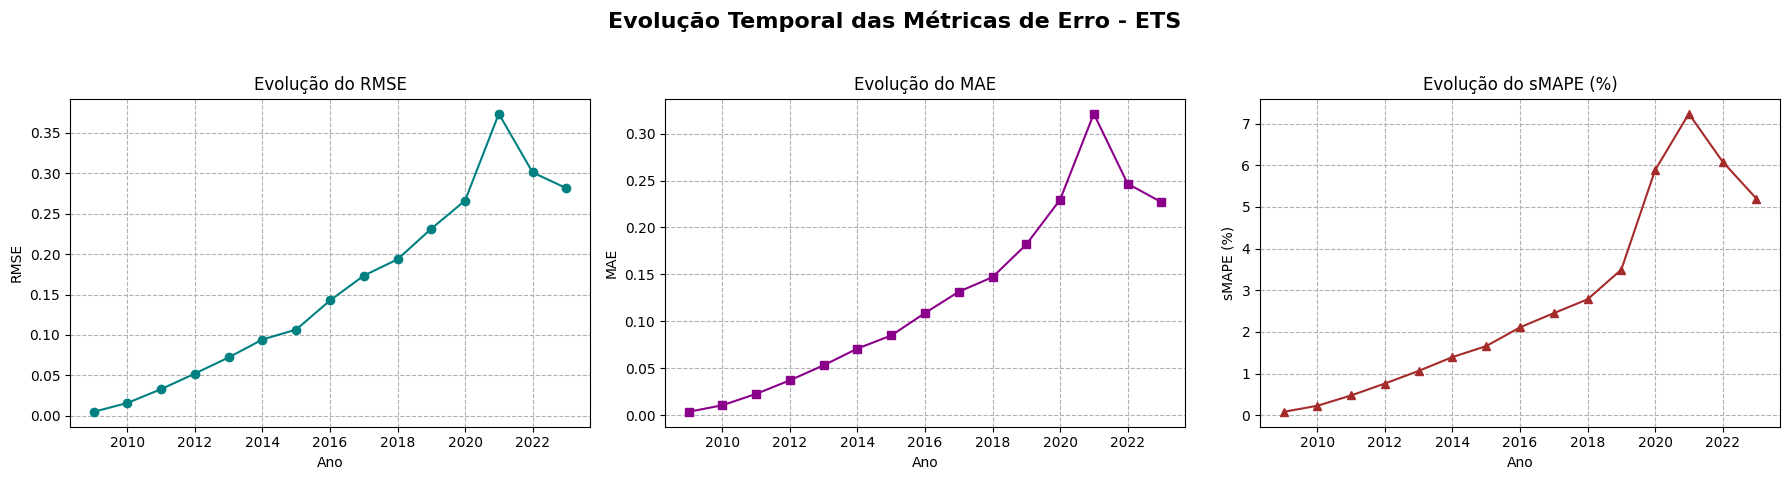

In [28]:

y_true_all = test_data.values.flatten()
y_pred_all = df_ets_test.values.flatten()

rmse_ets = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
mae_ets = mean_absolute_error(y_true_all, y_pred_all)
smape_ets = smape(y_true_all, y_pred_all)

print(f'Métricas ETS Globais (Dados de Teste):')
print(f'RMSE:  {rmse_ets:.4f}')
print(f'MAE:   {mae_ets:.4f}')
print(f'sMAPE: {smape_ets:.4f}%\n')

# Por ano
ets_metrics_list = []
for year in years_test:
    y_true_year = test_data[year].values
    y_pred_year = df_ets_test[year].values

    rmse = np.sqrt(mean_squared_error(y_true_year, y_pred_year))
    mae = mean_absolute_error(y_true_year, y_pred_year)
    smape_val = smape(y_true_year, y_pred_year)

    ets_metrics_list.append({
        'Ano': year,
        'RMSE': rmse,
        'MAE': mae,
        'sMAPE (%)': smape_val
    })

# Armazenar em DF
df_metrics_ets = pd.DataFrame(ets_metrics_list)
display(df_metrics_ets)

# Visualização da evolução
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Evolução Temporal das Métricas de Erro - ETS', fontsize=16, fontweight='bold')

# RMSE Plot
axes[0].plot(df_metrics_ets['Ano'], df_metrics_ets['RMSE'], marker='o', color='teal', label='RMSE')
axes[0].set_title('Evolução do RMSE')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('RMSE')
axes[0].grid(True, linestyle='--')

# MAE Plot
axes[1].plot(df_metrics_ets['Ano'], df_metrics_ets['MAE'], marker='s', color='darkmagenta', label='MAE')
axes[1].set_title('Evolução do MAE')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('MAE')
axes[1].grid(True, linestyle='--')

# sMAPE Plot
axes[2].plot(df_metrics_ets['Ano'], df_metrics_ets['sMAPE (%)'], marker='^', color='brown', label='sMAPE (%)')
axes[2].set_title('Evolução do sMAPE (%)')
axes[2].set_xlabel('Ano')
axes[2].set_ylabel('sMAPE (%)')
axes[2].grid(True, linestyle='--')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [29]:
# 1. dict com os erros
final_data = {
    'Modelo': ['Lee-Carter', 'Auto ARIMA', 'ETS'],
    'RMSE': [rmse_lc, rmse_arima, rmse_ets],
    'MAE': [mae_lc, mae_arima, mae_ets],
    'sMAPE (%)': [smape_lc, smape_arima, smape_ets]
}

# 2. Converter para dataframe
df_final_comparison = pd.DataFrame(final_data)

# 3. Mostrar a tabela
print('Comparação Final de Modelos Estatísticos (Conjunto de Teste 2009-2023):')
display(df_final_comparison)

Comparação Final de Modelos Estatísticos (Conjunto de Teste 2009-2023):


,Modelo,RMSE,MAE,sMAPE (%)
0,Lee-Carter,0.234045,0.190532,3.900534
1,Auto ARIMA,0.175701,0.107137,2.342789
2,ETS,0.191731,0.125187,2.726823


## Modelos de Deep Learning (Redes Neurais Artificiais Profundas)

• O *deep learning* tem sido cada vez mais utilizado em previsão de séries temporais por sua capacidade de aprender padrões
  complexos diretamente dos dados. Diferentemente de modelos estatísticos clássicos, que geralmente dependem de hipóteses
  mais estruturadas sobre a série, os modelos de aprendizado profundo buscam capturar relações não lineares, dependências de
  curto e longo prazo e interações complexas entre variáveis, o que os torna especialmente interessantes em problemas com grande
  volume de dados ou com dinâmica temporal mais complexa.

• Entre as arquiteturas mais conhecidas estão as redes neurais recorrentes - RNN (*Recurrent Neural Networks*), modelos projetados para capturar dependências temporais por meio de estados internos que evoluem ao longo das sequências, como as LSTM (*Long Short-Term Memory*) e as GRU (*Gated Recurrent Units*), que foram desenvolvidas para lidar com dados sequenciais e preservar informações ao longo do tempo. Mais recentemente, arquiteturas como Transformers, CNN (*Convolutional Neural Networks*) e modelos fundacionais de séries temporais também passaram a ser aplicadas com bons resultados. Em geral, essas abordagens recebem como entrada uma janela de observações passadas e aprendem uma função capaz de produzir previsões para um ou mais passos à frente.

• Apesar do seu potencial, o uso de *deep learning* em séries temporais exige alguns cuidados. Esses modelos costumam demandar
  maior quantidade de dados, maior custo computacional e uma etapa mais cuidadosa de ajuste de hiperparâmetros. Além disso,
  nem sempre superam modelos mais simples, especialmente em séries curtas, pouco ruidosas ou com estrutura bem comportada.
  Por isso, do ponto de vista prático, o *deep learning* deve ser visto como uma ferramenta poderosa, mas não como solução
  automática para todo problema de previsão.


Modelos de *Deep Learning* possuem a propriedade de extração de características automática (feature extractor). Ou seja, você não precisa declarar manualmente quais as relações matemáticas entre as variáveis de entrada.

<img width='800x' src='https://aitools4actuaries.com/Ch5A/FNN1.png'>

**Fonte**: AITools for actuaries.




### Convolution Neural Network (CNN)


Uma Rede Neural Convolucional 1D (CNN 1D) aplica filtros deslizantes sobre uma sequência temporal para detectar padrões locais da mesma forma que uma CNN 2D detecta bordas e texturas em imagens, mas operando em uma única dimensão (o tempo).

Como a convolução funciona no tempo

O kernel desliza sobre a sequência multiplicando pesos locais:

  Sequência:  [3, 5, 2, 8, 6, 1]
  
  Kernel:         [w1, w2, w3]

  Passo 1: w1·3 + w2·5 + w3·2 = saída_1

  Passo 2: w1·5 + w2·2 + w3·8 = saída_2
  ...

Cada filtro aprende a reconhecer um padrão temporal específico (ex.: subida abrupta, platô, decaimento).

----
  
**Figura** - Operação de convolução para uma matriz que representa uma imagem

<img width='800x' src='https://editor.analyticsvidhya.com/uploads/24603filter%20mat%203.PNG'>


**Fonte**: https://www.analyticsvidhya.com/blog/2021/08/hands-on-stock-price-time-series-forecasting-using-deep-convolutional-networks/

----

**Figura** - Operação de Max Pooling

<img width='800x' src='https://editor.analyticsvidhya.com/uploads/47293max-pooled%20matrix.PNG'>

**Fonte**: https://www.analyticsvidhya.com/blog/2021/08/hands-on-stock-price-time-series-forecasting-using-deep-convolutional-networks/


----

**Figura** - Modelo CNN para previsão de séries temporais

<img width='800x' src='https://editor.analyticsvidhya.com/uploads/97716cnn%20time%20full%20image.PNG'>

**Fonte**: Python for Finance Cookbook.



### Long Short-Term Memory (LSTM)


Enquanto a CNN 1D enxerga a série como um bloco fixo e extrai padrões locais, a LSTM (Long Short-Term Memory) lê a série passo a passo, mantendo uma memória interna que se atualiza a cada timestep.

A ideia central é simples: a rede aprende o que vale a pena lembrar, o que esquecer e o que usar para fazer a previsão.

  A célula LSTM

  A LSTM mantém dois vetores internos entre os timesteps:

  - h_t — estado oculto: o que a rede "comunica" para o próximo passo
  - c_t — estado da célula: a memória de longo prazo

  A cada passo t, três portões (gates) controlam o fluxo de informação:

|Portão| Pergunta que responde|
| :--- | :---: |
|Forget gate| o que foi lembrado até agora, o que devo descartar?|
| Input gate | do que estou vendo agora, o que merece ser memorizado? |
| Output gate | o que a memória atual devo expor como saída? |

----

Cada portão produz valores entre 0 e 1 — funcionam como válvulas que abrem ou fecham o fluxo de informação.

  Fluxo de processamento

  Timestep 1: x_1 → [LSTM cell] → h_1, c_1
  
  Timestep 2: x_2 → [LSTM cell] → h_2, c_2   (usa h_1 e c_1)
  
  Timestep 3: x_3 → [LSTM cell] → h_3, c_3   (usa h_2 e c_2)
  
  ...
  
  Timestep L: x_L → [LSTM cell] → h_L  →  Dense  →  ŷ_{t+h}

  O estado final h_L resume toda a sequência e é passado para uma camada densa que produz a previsão.

**Figura** - Modelo LSTM

<img width='800x' src='https://d2l.ai/_images/lstm-3.svg'>
**Fonte**: Dive Deep into Deep Learning (https://d2l.ai/chapter_recurrent-modern/lstm.html).




### Transformer


 O Transformer abandona completamente a recorrência e a convolução. Em vez de processar a série passo a passo ou com janelas deslizantes, ele olha para todos os timesteps simultaneamente e aprende diretamente quais posições da série são mais relevantes entre si.

O mecanismo central é a atenção a capacidade de, ao processar o timestep t, consultar qualquer outro timestep da sequência e ponderar sua importância.

  ---
  O problema do Transformer original com séries temporais

  O Transformer foi projetado para texto (sequências de tokens discretos). Aplicado diretamente a séries temporais, enfrenta dois problemas:

  1. Sem noção de ordem — a arquitetura é invariante à permutação. É preciso injetar a posição explicitamente via positional encoding.
  
  2. Custo quadrático — a atenção compara cada timestep com todos os outros: para uma sequência de L passos, o custo é O(L²). Sequências longas ficam proibitivas.

  
---
Self-Attention funciona da seguinte forma:

  Para cada timestep, a atenção faz três perguntas:

  - Query: "O que estou procurando?"

  - Key: "O que cada posição da sequência oferece?"
  
  - Value: "Qual informação efetivamente extraio de cada posição?"

  O resultado é uma média ponderada dos Values, onde os pesos são determinados pela compatibilidade entre Query e Keys. Posições muito relevantes recebem peso alto; posições irrelevantes recebem peso próximo de zero.


Multi-head: esse processo é executado em paralelo com múltiplos conjuntos de pesos, permitindo que o modelo capture diferentes tipos de dependência ao mesmo tempo (ex.: sazonalidade curta e tendência de longo prazo).




**Figura** - O modelo de Transformer

<img width='400x' src='https://www.tensorflow.org/images/tutorials/transformer/transformer.png'>

**Fonte**: https://www.tensorflow.org/text/tutorials/transformer?hl=pt-br.

In [30]:
# Construção dos modelos:

class CNN1D_Model(nn.Module):
    def __init__(self, input_size, filters, kernel_size, stride, output_size, seed=100):
        super(CNN1D_Model, self).__init__()
        torch.manual_seed(seed)

        # Camada convolucional 1D: extrai padrões locais ao longo da sequência temporal
        self.conv1d = nn.Conv1d(
            in_channels=input_size[1],   # número de features de entrada
            out_channels=filters,         # número de filtros (mapas de características)
            kernel_size=kernel_size,      # tamanho da janela deslizante
            stride=stride,               # passo entre cada aplicação do filtro
        )

        # Calcula o comprimento da saída após a convolução
        conv_output_size = ((input_size[0] - kernel_size) // stride) + 1

        # Tamanho total após achatar (filters × comprimento resultante)
        self.flatten_size = filters * conv_output_size

        # Camada densa de saída: mapeia features extraídas para o horizonte de previsão
        self.dense = nn.Linear(self.flatten_size, output_size)

    def forward(self, x):
        # x shape: (batch_size, seq_len, features)
        # Permute for Conv1D: (batch_size, features, seq_len)
        # Torch Notation: (N, C_in, L_in)
        x = x.permute(0, 2, 1)
        x = self.conv1d(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.dense(x)
        return x


class CNN1D_Tanh_Model(nn.Module):
    def __init__(
        self,
        input_size,
        filters,
        kernel_size,
        stride,
        output_size,
        seed=100,
        qq=[20, 50],
    ):
        super(CNN1D_Tanh_Model, self).__init__()
        torch.manual_seed(seed)

        # Camada densa inicial: projeta as features de entrada para um espaço intermediário
        self.dense_1 = nn.Linear(input_size[1], qq[0])

        # Camada convolucional 1D: captura dependências locais na sequência projetada
        self.conv1d = nn.Conv1d(
            in_channels=qq[0],       # dimensão intermediária vinda da dense_1
            out_channels=filters,     # número de filtros convolucionais
            kernel_size=kernel_size,  # tamanho da janela deslizante
            stride=stride,           # passo entre aplicações do filtro
        )

        # Calcula o comprimento da saída após a convolução
        conv_output_size = ((input_size[0] - kernel_size) // stride) + 1

        # Tamanho total após achatar (filters × comprimento resultante)
        self.flatten_size = filters * conv_output_size

        # Camadas densas após o achatamento: refinam a representação e produzem a saída
        self.dense_2 = nn.Linear(self.flatten_size, qq[1])
        self.dense_3 = nn.Linear(qq[1], output_size)

    def forward(self, x, gender=None):
        x = torch.tanh(self.dense_1(x))
        x = x.permute(0, 2, 1)
        x = self.conv1d(x)
        x = x.view(x.size(0), -1)
        x = torch.tanh(self.dense_2(x))
        x = self.dense_3(x)
        return x


class LSTM_Model(nn.Module):
    def __init__(self, input_size, q, units, output_size, seed=100):
        super(LSTM_Model, self).__init__()
        torch.manual_seed(seed)

        # Projeção temporal: reduz/expande a dimensão de features em cada passo de tempo
        self.time_dense = nn.Linear(input_size[1], q)

        # Camada LSTM: captura dependências de longo prazo na sequência temporal
        # batch_first=True → entrada no formato (batch_size, seq_len, features)
        self.lstm = nn.LSTM(q, units, batch_first=True)

        # Camada densa de saída: mapeia o estado oculto final para o horizonte de previsão
        self.output_dense = nn.Linear(units, output_size)

    def forward(self, x):
        x = self.time_dense(x)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # Use last time step
        x = lstm_out[:, -1, :]
        x = self.output_dense(x)
        return x


class TRANSF_Model(nn.Module):
    def __init__(self, input_size, units, output_size, seed=100):
        super(TRANSF_Model, self).__init__()
        torch.manual_seed(seed)
        self.units = units
        self.seq_len = input_size[0]

        # Projeção de representação: eleva as features brutas para o espaço de dimensão `units`
        self.representation = nn.Linear(input_size[1], units)

        # Projeções lineares para Q, K e V do mecanismo de atenção
        self.query_layer = nn.Linear(units, units)
        self.key_layer   = nn.Linear(units, units)
        self.value_layer = nn.Linear(units, units)

        # Normalização de camada: estabiliza a distribuição após a atenção
        self.layer_norm = nn.LayerNorm(units)

        # Feed-forward pós-atenção: bloco não-linear com ativação ReLU
        self.ff1 = nn.Linear(units, units)
        self.ff2 = nn.Linear(units, units)

        # Camada densa de saída: achata todos os passos de tempo e projeta para a previsão
        self.output_dense = nn.Linear(units * input_size[0], output_size)

    def forward(self, x):
        representation = self.representation(x)
        query = self.query_layer(representation)
        key = self.key_layer(representation)
        value = self.value_layer(representation)
        # Scaled dot-product attention
        scores = torch.matmul(query, key.transpose(-2, -1)) / torch.sqrt(
            torch.tensor(self.units, dtype=torch.float32)
        )
        attention_weights = torch.softmax(scores, dim=-1)
        attention_output = torch.matmul(attention_weights, value)
        skip_1 = attention_output + representation
        normalized = self.layer_norm(skip_1)

        skip_2 = self.ff2(self.ff1(normalized))
        # Feed-forward com ReLU - não linearidade que não vamos abordar agora por conta da complexidade e do volume de dados
        # skip_2 = self.ff2(torch.relu(self.ff1(normalized)))

        features = skip_2 + skip_1
        features = features.view(features.size(0), -1)  # Flatten
        output = self.output_dense(features)
        return output

Se atentar para o fato de que o dataset que estamos utilizando é pequeno para os modelos de *deep learning* que vamos utilizar. Recomenda-se que o conjunto de dados seja grande. Uma ideia interessante seria utilizar os modelos para múltiplas populações.  

In [31]:
"""
Preparação dos dados de treino usando df_pivot (Age × Year)
=============================================================
Entradas esperadas:
  df_pivot   — DataFrame, índice=Age (int), colunas=Year (int), valores=logmx
  learn      — df_pivot.loc[:, df_pivot.columns <= obs_year]
  obs_year   — int, ano de corte
  scaler     — instância de MinMaxScaler (importada, ainda não fittada)
  lookback   — int, número de anos anteriores usados como covariável

Saídas criadas no namespace:
  learn_scaled      — DataFrame (Age × Year), valores escalados
  scaler            — MinMaxScaler fittado (in-place, pronto para inverse_transform)
  x_learn / y_learn — arrays numpy
  x_train_tensor, y_train_tensor, x_learn_tensor — tensores PyTorch
"""

# ── CONFIGURAÇÕES ─────────────────────────────────────────────────────────────
lookback = 5 # usar 5 anos passados em cada janela
first_year = df2.Time.iloc[0]
obs_year = 2008
n_age    = train_data.shape[0]
n_sample = len(range(first_year + lookback, obs_year + 1))

print(f"Number of samples : {n_sample}")
print(f"Number of ages    : {n_age}")



Number of samples : 54
Number of ages    : 20


In [32]:
# ── SCALING ───────────────────────────────────────────────────────────────────
# Faz o fit em shape (n_years, n_age) — cada coluna é uma feature (idade).
# O inverse_transform em predict_and_forecast recebe (1, n_age): mesmo shape → OK.
learn_T_scaled = scaler.fit_transform(learn.T.values)      # (n_years, n_age)
learn_scaled = pd.DataFrame(
    learn_T_scaled.T,        # volta para (n_age, n_years)
    index   = learn.index,
    columns = learn.columns,
)

# Faz o transform em test
test_T_scaled = scaler.transform(test_data.T.values)
test_scaled = pd.DataFrame(
    test_T_scaled.T,
    index   = test_data.index,
    columns = test_data.columns,
)

# concatena learn and test
learn_test = pd.concat([learn_scaled, test_scaled], axis=1)


# ── PREPARAÇÃO DE x_learn e y_learn ──────────────────────────────────────────
x_learn = np.zeros((n_sample, lookback, n_age))
y_learn = np.zeros((n_sample, n_age))

for i, year in enumerate(range(first_year + lookback, obs_year + 1)):
    lookback_cols = list(range(year - lookback, year))
    # x_learn[i] = learn_scaled[lookback_cols].T.values   # (lookback, n_age)
    # y_learn[i] = learn_scaled[year].values               # (n_age,)
    x_learn[i] = learn_test[lookback_cols].T.values   # (lookback, n_age)
    y_learn[i] = learn_test[year].values               # (n_age,)


print(f"Final training data shape: x_learn={x_learn.shape}, y_learn={y_learn.shape}")

# ── SHUFFLE ───────────────────────────────────────────────────────────────────
np.random.seed(100)
indices          = np.random.permutation(len(x_learn))
x_learn_shuffled = x_learn[indices]
y_learn_shuffled = y_learn[indices]

# ── TENSORES ──────────────────────────────────────────────────────────────────
x_train_tensor = torch.FloatTensor(x_learn_shuffled)
y_train_tensor = torch.FloatTensor(y_learn_shuffled)
x_learn_tensor = torch.FloatTensor(x_learn)

print(f"Scaler fitted: min shape={scaler.data_min_.shape}, max shape={scaler.data_max_.shape}")
print(f"  → inverse_transform espera shape (n_samples, {n_age})")

Final training data shape: x_learn=(54, 5, 20), y_learn=(54, 20)
Scaler fitted: min shape=(20,), max shape=(20,)
  → inverse_transform espera shape (n_samples, 20)


In [33]:
def train_model(
    model, x_learn, y_learn, epochs=500, batch_size=4, lr=0.001, patience=5
):
    # Otimizador Adam com taxa de aprendizado inicial
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Função de perda: erro quadrático médio (regressão)
    criterion = nn.MSELoss()

    # Scheduler: reduz o lr em 10% se a val_loss não melhorar por `patience` épocas
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, factor=0.9, patience=patience
    )

    # Separa os últimos 10% de x_learn como validação interna
    val_split = int(0.9 * len(x_learn))
    x_val   = x_learn[val_split:]
    y_val   = y_learn[val_split:]
    x_train = x_learn[:val_split]
    y_train = y_learn[:val_split]

    train_losses = []
    val_losses = []
    best_val_loss = float("inf")

    for epoch in range(epochs):
        model.train()

        # Mini-batch SGD: percorre os dados de treino em lotes de tamanho `batch_size`
        for i in range(0, len(x_train), batch_size):
            batch_x = x_train[i : i + batch_size]
            batch_y = y_train[i : i + batch_size]

            optimizer.zero_grad()           # limpa gradientes do passo anterior
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()                 # backpropagation
            optimizer.step()               # atualiza os pesos

        # Avaliação ao final de cada época (sem computar gradientes)
        model.eval()
        with torch.no_grad():
            val_loss   = criterion(model(x_val),   y_val).item()
            train_loss = criterion(model(x_train), y_train).item()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Ajusta o lr com base na perda de validação
        scheduler.step(val_loss)

        # Early stopping: salva o estado do modelo quando val_loss atinge novo mínimo
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = deepcopy(model.state_dict())

        if epoch % 100 == 0:
            print(
                f"Epoch {epoch}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}"
            )

    # Restaura os pesos do melhor checkpoint encontrado durante o treino
    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses

### Treinando modelos de Deep Learning

In [34]:
from copy import deepcopy

"""
Predição, forecast e avaliação usando df_pivot (Age × Year)
=============================================================
Entradas esperadas:
  df_pivot      — DataFrame, índice=Age (int), colunas=Year (int), valores=logmx
  learn         — df_pivot.loc[:, colunas <= obs_year]
  test          — df_pivot.loc[:, colunas >  obs_year]
  learn_scaled  — learn após MinMaxScaler (mesmo shape, Age × Year)
  x_learn_tensor — torch.FloatTensor já preparado
  obs_year      — int
  scaler        — MinMaxScaler fitado no learn
"""
def predict_and_forecast(model, model_name, x_learn_tensor, df_pivot,
                         learn_scaled, obs_year, scaler):
    """
    Retorna df_pivot_pred (Age × Year) com as predições in-sample + forecast,
    no mesmo formato do df_pivot (logmx na escala original).
    """
    model.eval()

    lookback   = x_learn_tensor.shape[1]
    n_age      = x_learn_tensor.shape[2]
    first_year = int(df_pivot.columns.min())
    last_year  = int(df_pivot.columns.max())
    ages       = list(df_pivot.index)

    pred_dict = {}   # year → array (n_age,) em escala original

    # ── IN-SAMPLE ─────────────────────────────────────────────────────────────
    with torch.no_grad():
        logmx_hat_learn = model(x_learn_tensor).detach().numpy()
        # shape: (n_sample, n_age), escala normalizada

    for i, year in enumerate(range(first_year + lookback, obs_year + 1)):
        pred_dict[year] = scaler.inverse_transform(
            logmx_hat_learn[[i]]          # (1, n_age)
        ).flatten()                        # (n_age,)

    # ── OUT-OF-SAMPLE (rolling forecast) ─────────────────────────────────────
    # Janela inicial: últimos `lookback` anos do learn, já escalados
    lookback_cols   = list(learn_scaled.columns[-lookback:])   # [obs_year-lb+1 … obs_year]
    starting_matrix = np.zeros((1, lookback, n_age))
    starting_matrix[0] = learn_scaled[lookback_cols].T.values  # (lookback, n_age)

    for year in range(obs_year + 1, last_year + 1):
        with torch.no_grad():
            starting_tensor = torch.FloatTensor(starting_matrix)
            y_pred_scaled   = model(starting_tensor).detach().numpy()[0]  # (n_age,)

        pred_dict[year] = scaler.inverse_transform(
            y_pred_scaled[None, :]         # (n_age, 1) → inverse → (n_age, 1)
        ).flatten()

        # Desloca janela: descarta o mais antigo, acrescenta o predito
        starting_matrix[0, :-1] = starting_matrix[0, 1:]
        starting_matrix[0, -1]  = y_pred_scaled

    # ── Monta df_pivot_pred (Age × Year) ──────────────────────────────────────
    df_pivot_pred = pd.DataFrame(pred_dict, index=ages)
    df_pivot_pred.index.name   = "Age"
    df_pivot_pred.columns.name = "Year"

    return df_pivot_pred

def evaluate_model(df_pivot, df_pivot_pred, model_name, obs_year, lookback):
    """
    Calcula RMSE, MAE e SMAPE in-sample e out-of-sample.
    Retorna dict com as 6 métricas.
    """
    first_year = int(df_pivot.columns.min())
    pred_years = df_pivot_pred.columns

    in_years  = [y for y in pred_years if first_year + lookback <= y <= obs_year]
    out_years = [y for y in pred_years if y > obs_year]

    def metrics(obs, pred):
        obs, pred = np.array(obs).flatten(), np.array(pred).flatten()
        rmse  = np.sqrt(np.mean((obs - pred) ** 2))
        mae   = np.mean(np.abs(obs - pred))
        smape = np.mean(2 * np.abs(obs - pred) / (np.abs(obs) + np.abs(pred) + 1e-8)) * 100
        return rmse, mae, smape

    in_rmse,  in_mae,  in_smape  = metrics(df_pivot[in_years],  df_pivot_pred[in_years])
    out_rmse, out_mae, out_smape = metrics(df_pivot[out_years], df_pivot_pred[out_years])

    print(
        f"{model_name:12s} | "
        f"In:  RMSE={in_rmse:.4f}  MAE={in_mae:.4f}  SMAPE={in_smape:.2f}%  | "
        f"Out: RMSE={out_rmse:.4f}  MAE={out_mae:.4f}  SMAPE={out_smape:.2f}%"
    )

    return {
        "in_rmse": in_rmse, "in_mae": in_mae, "in_smape": in_smape,
        "out_rmse": out_rmse, "out_mae": out_mae, "out_smape": out_smape,
    }


# --- Define model configurations here ---
input_size = (x_train_tensor.shape[1], x_train_tensor.shape[2]) # (lookback, n_age)
output_size = y_train_tensor.shape[1] # n_age

model_configs = {
    "CNN": {
        "name": "CNN",
        "model": CNN1D_Model(
            input_size=input_size,
            filters=64,
            kernel_size=3,
            stride=1,
            output_size=output_size,
        ),
    },
    "CNN_TANH": {
        "name": "CNN_TANH",
        "model": CNN1D_Tanh_Model(
            input_size=input_size,
            filters=64,
            kernel_size=3,
            stride=1,
            output_size=output_size,
            qq=[20, 50],
        ),
    },
    "LSTM": {
        "name": "LSTM",
        "model": LSTM_Model(
            input_size=input_size,
            q=32, # Latent dimension for time_dense
            units=64, # LSTM units
            output_size=output_size,
        ),
    },
    "TRANS": {
        "name": "Transformer",
        "model": TRANSF_Model(
            input_size=input_size,
            units=64, # Transformer units
            output_size=output_size,
        ),
    },
}
# ------------------------------------------

trained_models  = {}
rmse_results    = {}
df_pivot_models = {}

# Lee-Carter
rmse_results["LC"] = evaluate_model(df_pivot, df_pivot_lc, "LC", obs_year, lookback)

for model_key, config in model_configs.items():
    print(f"\nTraining {config['name']} model...")

    model, train_losses, val_losses = train_model(
        config["model"], x_train_tensor, y_train_tensor, epochs=1000
    )
    trained_models[model_key] = model

    df_pivot_pred = predict_and_forecast(
        model, config["name"], x_learn_tensor,
        df_pivot, learn_scaled, obs_year, scaler,
    )
    df_pivot_models[model_key] = df_pivot_pred

    rmse_results[config["name"]] = evaluate_model(
        df_pivot, df_pivot_pred, config["name"], obs_year, lookback
    )

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{config['name']} - Number of parameters: {n_params}")

LC           | In:  RMSE=0.0527  MAE=0.0376  SMAPE=1.11%  | Out: RMSE=0.2340  MAE=0.1905  SMAPE=3.90%

Training CNN model...
Epoch 0: Train Loss = 0.021562, Val Loss = 0.020938
Epoch 100: Train Loss = 0.000292, Val Loss = 0.000382
Epoch 200: Train Loss = 0.000173, Val Loss = 0.000202
Epoch 300: Train Loss = 0.000126, Val Loss = 0.000138
Epoch 400: Train Loss = 0.000110, Val Loss = 0.000116
Epoch 500: Train Loss = 0.000100, Val Loss = 0.000106
Epoch 600: Train Loss = 0.000092, Val Loss = 0.000096
Epoch 700: Train Loss = 0.000089, Val Loss = 0.000090
Epoch 800: Train Loss = 0.000084, Val Loss = 0.000082
Epoch 900: Train Loss = 0.000081, Val Loss = 0.000078
CNN          | In:  RMSE=0.0074  MAE=0.0053  SMAPE=0.16%  | Out: RMSE=0.2871  MAE=0.2074  SMAPE=4.78%
CNN - Number of parameters: 7764

Training CNN_TANH model...
Epoch 0: Train Loss = 0.047809, Val Loss = 0.042746
Epoch 100: Train Loss = 0.000427, Val Loss = 0.000544
Epoch 200: Train Loss = 0.000199, Val Loss = 0.000206
Epoch 300: Tra

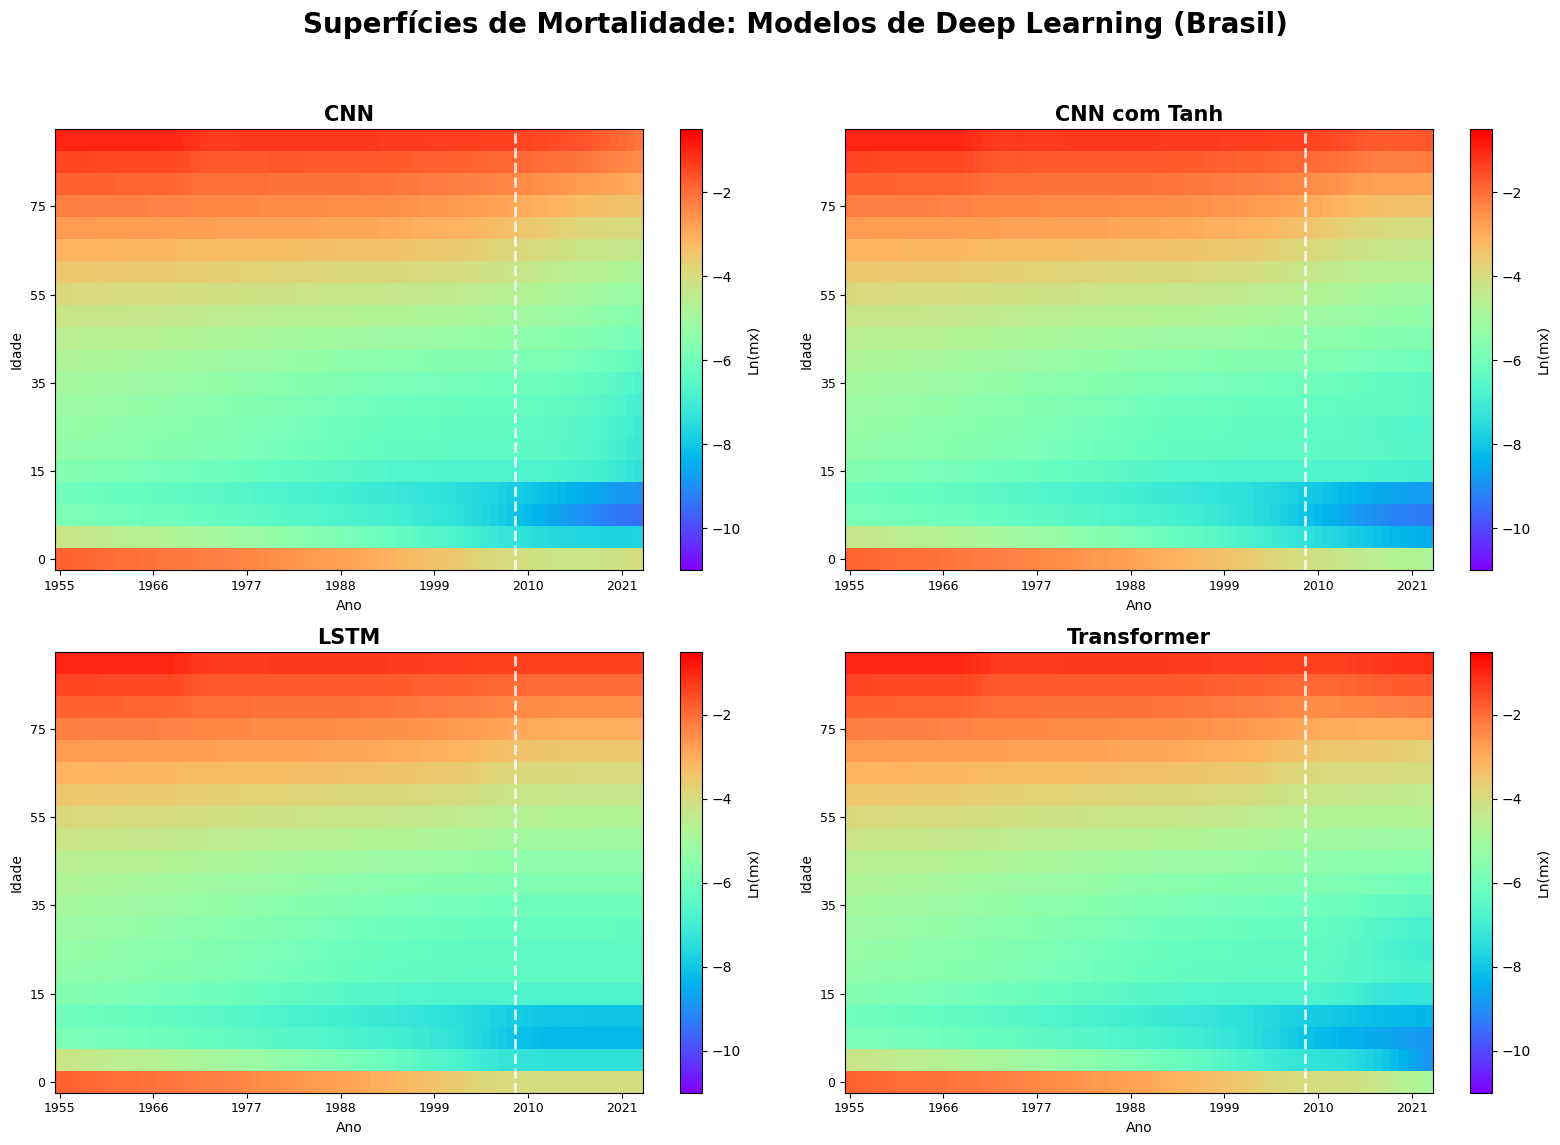

In [35]:
# Configuração da grade de subplots (2x2 para os 4 modelos)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Superfícies de Mortalidade: Modelos de Deep Learning (Brasil)', fontsize=20, fontweight='bold')

# Lista de chaves e títulos para o loop
model_keys = ['CNN', 'CNN_TANH', 'LSTM', 'TRANS']
model_titles = ['CNN', 'CNN com Tanh', 'LSTM', 'Transformer']

# Iterar sobre os modelos e plotar os heatmaps
for i, key in enumerate(model_keys):
    row = i // 2
    col = i % 2
    ax = axes[row, col]

    # Usamos os dados armazenados no dicionário df_pivot_models
    mat_data = df_pivot_models[key].values

    # Reutilizando a lógica de plotagem consistente
    im = ax.imshow(mat_data, aspect='auto', cmap='rainbow', vmin=-11, vmax=-0.5, origin='lower')
    ax.set_title(model_titles[i], fontsize=15, fontweight='bold')
    ax.set_xlabel('Ano')
    ax.set_ylabel('Idade')

    # Ticks de anos e idades
    n_years_pred = mat_data.shape[1]
    n_ages_pred = mat_data.shape[0]
    # Nota: df_pivot_pred começa em first_year + lookback
    pred_years = list(df_pivot_models[key].columns)
    pred_ages = list(df_pivot_models[key].index)

    ax.set_xticks(range(0, n_years_pred, max(1, n_years_pred // 6)))
    ax.set_xticklabels([str(pred_years[j]) for j in range(0, n_years_pred, max(1, n_years_pred // 6))], fontsize=9)
    ax.set_yticks(range(0, n_ages_pred, max(1, n_ages_pred // 5)))
    ax.set_yticklabels([str(pred_ages[j]) for j in range(0, n_ages_pred, max(1, n_ages_pred // 5))], fontsize=9)

    # Linha vertical no ano de corte (obs_year)
    # Encontrar o índice do obs_year nas colunas do modelo
    try:
        cut_year_idx = pred_years.index(obs_year)
        ax.axvline(cut_year_idx + 0.5, color='white', linewidth=2, linestyle='--', alpha=0.8)
    except ValueError:
        pass

    plt.colorbar(im, ax=ax, label='Ln(mx)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

dl_metrics_results = {}
model_mapping = {
    'CNN': 'CNN',
    'CNN_TANH': 'CNN_TANH',
    'LSTM': 'LSTM',
    'TRANS': 'Transformer'
}

# 1. Itera sobre cada modelo de Deep Learning
for key, model_name in model_mapping.items():
    df_pred_all = df_pivot_models[key]
    # Filtra apenas os anos do período de teste
    df_pred_test = df_pred_all[years_test]

    # 2. Métricas globais (vetores achatados sobre todas as idades e anos)
    y_true_flat = test_data.values.flatten()
    y_pred_flat = df_pred_test.values.flatten()

    rmse_global  = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
    mae_global   = mean_absolute_error(y_true_flat, y_pred_flat)
    smape_global = smape(y_true_flat, y_pred_flat)

    print(f'Métricas Globais {model_name}: RMSE={rmse_global:.4f}, MAE={mae_global:.4f}, sMAPE={smape_global:.4f}%')

    # 3. Métricas anuais: calcula RMSE, MAE e sMAPE para cada ano do teste
    yearly_data = []
    for year in years_test:
        y_true_year = test_data[year].values
        y_pred_year = df_pred_test[year].values

        rmse  = np.sqrt(mean_squared_error(y_true_year, y_pred_year))
        mae   = mean_absolute_error(y_true_year, y_pred_year)
        s_val = smape(y_true_year, y_pred_year)

        yearly_data.append({
            'Ano': year,
            'RMSE': rmse,
            'MAE': mae,
            'sMAPE (%)': s_val,
            'Modelo': model_name
        })

    # 4. Armazena as métricas anuais em um DataFrame individual por modelo
    dl_metrics_results[key] = pd.DataFrame(yearly_data)

df_metrics_cnn      = dl_metrics_results['CNN']
df_metrics_cnn_tanh = dl_metrics_results['CNN_TANH']
df_metrics_lstm     = dl_metrics_results['LSTM']
df_metrics_trans    = dl_metrics_results['TRANS']

display(df_metrics_lstm.head())

Métricas Globais CNN: RMSE=0.2871, MAE=0.2074, sMAPE=4.7810%
Métricas Globais CNN_TANH: RMSE=0.2554, MAE=0.1883, sMAPE=4.4032%
Métricas Globais LSTM: RMSE=0.1310, MAE=0.0943, sMAPE=2.0426%
Métricas Globais Transformer: RMSE=0.2056, MAE=0.1287, sMAPE=2.9966%


,Ano,RMSE,MAE,sMAPE (%),Modelo
0,2009,0.013514,0.008622,0.210825,LSTM
1,2010,0.024085,0.016672,0.425601,LSTM
2,2011,0.034998,0.025907,0.689112,LSTM
3,2012,0.053709,0.041529,1.058619,LSTM
4,2013,0.069799,0.056362,1.418822,LSTM


### Tabela de Erros por Ano


In [37]:
# 1. Prepara as métricas dos modelos estatísticos com coluna identificadora
# df_metrics_years foi criado para o Lee-Carter
df_metrics_lc_yearly = df_metrics_years.copy()
df_metrics_lc_yearly['Modelo'] = 'Lee-Carter'

# df_metrics_arima já foi criado para o ARIMA
df_metrics_arima_yearly = df_metrics_arima.copy()
df_metrics_arima_yearly['Modelo'] = 'Auto ARIMA'

# df_metrics_ets já foi criado para o ETS
df_metrics_ets_yearly = df_metrics_ets.copy()
df_metrics_ets_yearly['Modelo'] = 'ETS'

# 2. Combina com as métricas de Deep Learning (já contêm a coluna 'Modelo')
# São elas: df_metrics_cnn, df_metrics_cnn_tanh, df_metrics_lstm, df_metrics_trans

# 3. Concatena todos os 7 DataFrames em um único
frames = [
    df_metrics_lc_yearly,
    df_metrics_arima_yearly,
    df_metrics_ets_yearly,
    df_metrics_cnn,
    df_metrics_cnn_tanh,
    df_metrics_lstm,
    df_metrics_trans
]

df_all_metrics_yearly = pd.concat(frames, ignore_index=True)

# 4. Ordena por modelo e ano
df_all_metrics_yearly = df_all_metrics_yearly.sort_values(by=['Modelo', 'Ano'])

# 5. Exibe a estrutura consolidada
print('DataFrame Mestre de Métricas Anuais Consolidado (7 Modelos):')
display(df_all_metrics_yearly.head(10))
print(f'Total de registros: {len(df_all_metrics_yearly)}')
print(f'Modelos incluídos: {df_all_metrics_yearly["Modelo"].unique()}')

DataFrame Mestre de Métricas Anuais Consolidado (7 Modelos):


,Ano,RMSE,MAE,sMAPE (%),Modelo
15,2009,0.005105,0.004018,0.093961,Auto ARIMA
16,2010,0.015646,0.010688,0.244310,Auto ARIMA
17,2011,0.031614,0.021001,0.480677,Auto ARIMA
18,2012,0.051038,0.035101,0.771281,Auto ARIMA
19,2013,0.069630,0.048766,1.050945,Auto ARIMA
20,2014,0.089739,0.063293,1.330064,Auto ARIMA
21,2015,0.098501,0.072528,1.517826,Auto ARIMA
22,2016,0.132541,0.091465,1.877963,Auto ARIMA
23,2017,0.157700,0.107852,2.119940,Auto ARIMA
24,2018,0.173831,0.117405,2.277935,Auto ARIMA


Total de registros: 105
Modelos incluídos: ['Auto ARIMA' 'CNN' 'CNN_TANH' 'ETS' 'LSTM' 'Lee-Carter' 'Transformer']


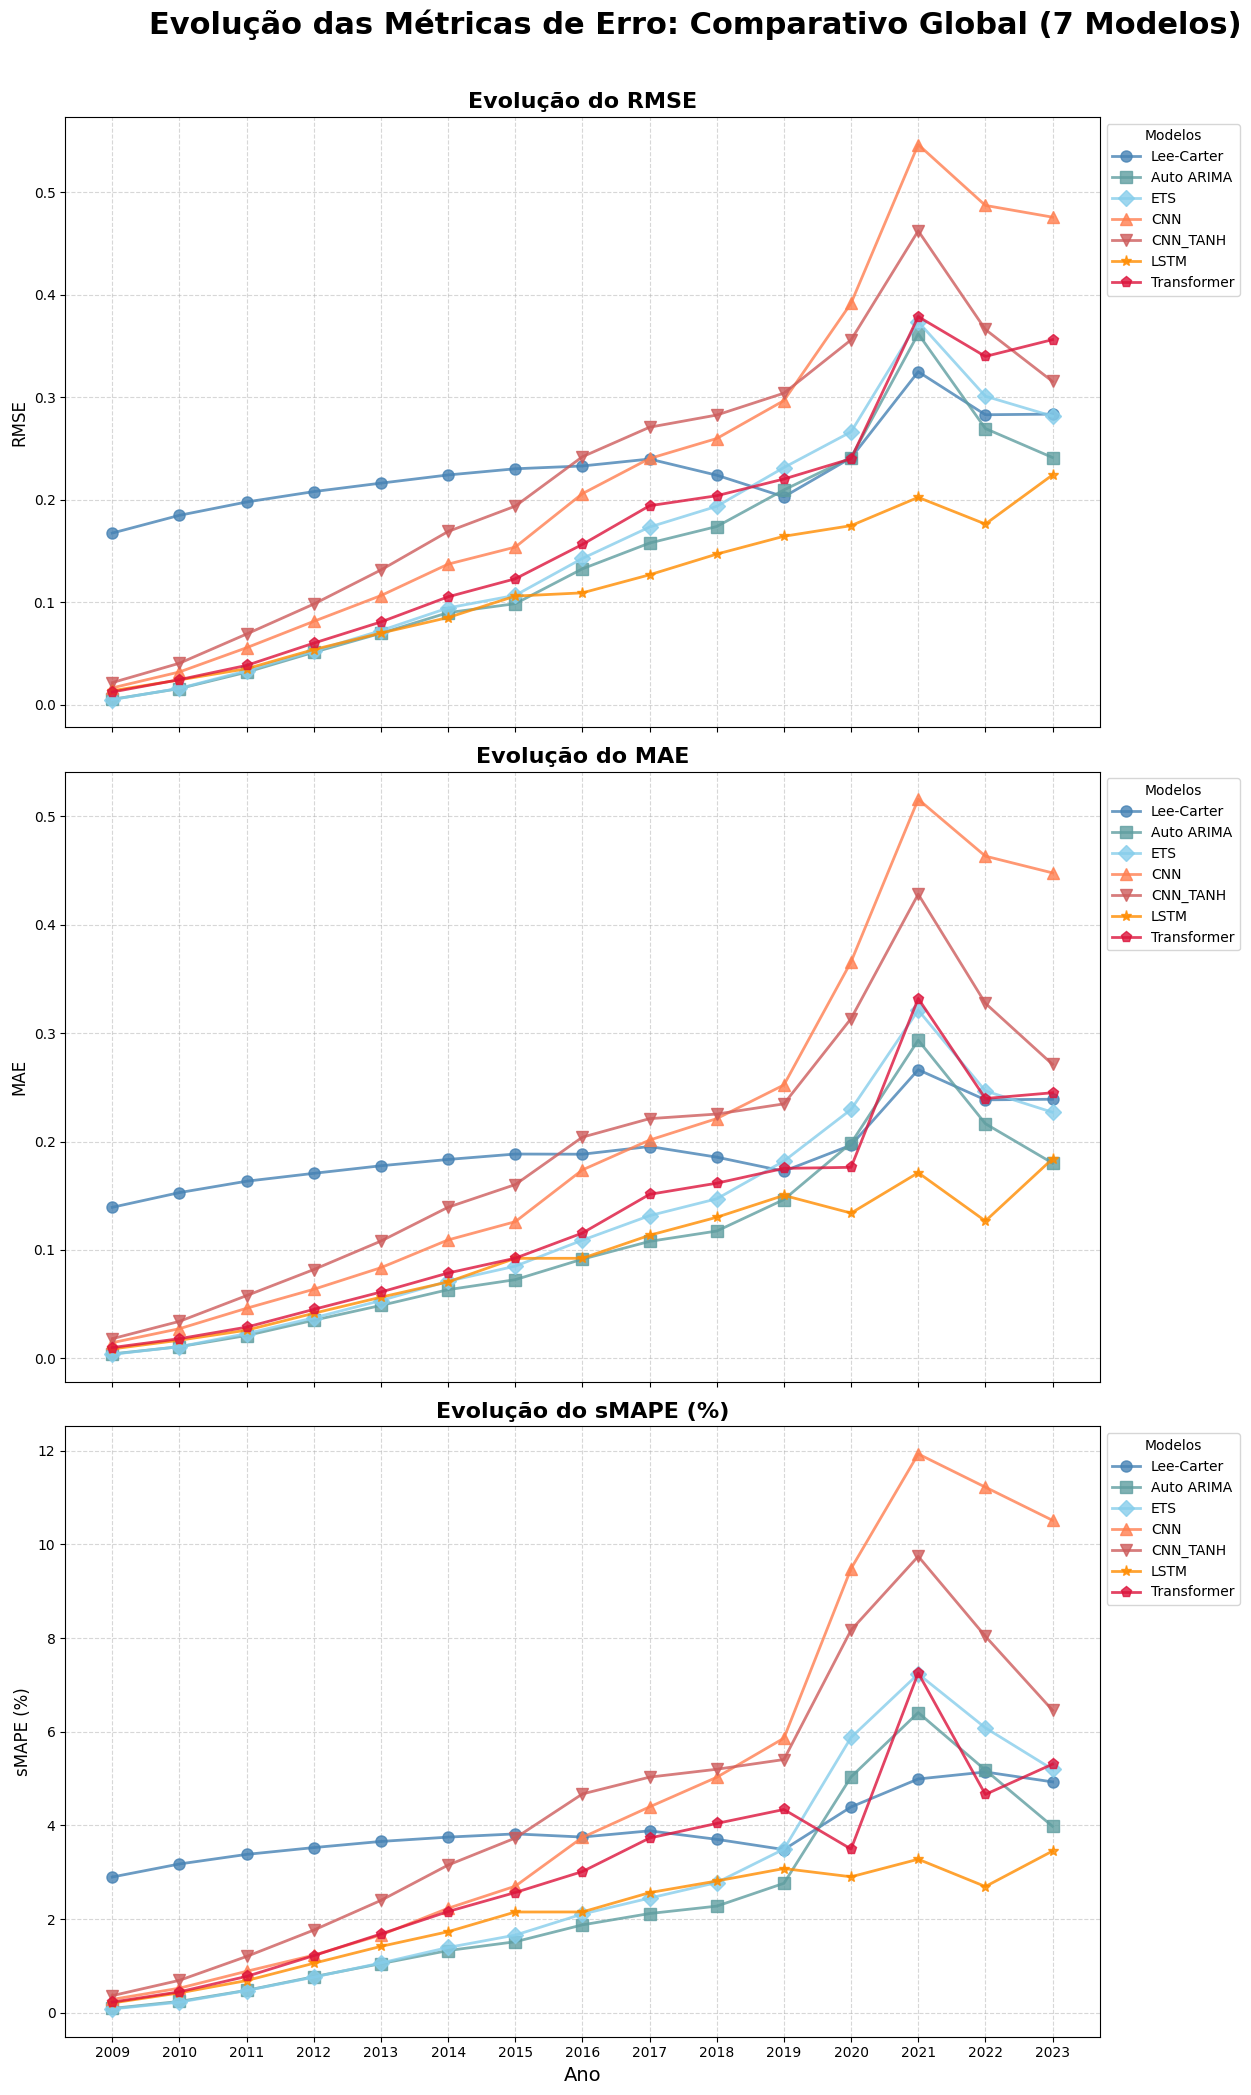

In [38]:
# 1. Definir todos os modelos e suas respectivas configurações visuais
all_model_names = ['Lee-Carter', 'Auto ARIMA', 'ETS', 'CNN', 'CNN_TANH', 'LSTM', 'Transformer']

color_map_all = {
    'Lee-Carter': 'steelblue',
    'Auto ARIMA': 'cadetblue',
    'ETS': 'skyblue',
    'CNN': 'coral',
    'CNN_TANH': 'indianred',
    'LSTM': 'darkorange',
    'Transformer': 'crimson'
}

marker_map = {
    'Lee-Carter': 'o',
    'Auto ARIMA': 's',
    'ETS': 'D',
    'CNN': '^',
    'CNN_TANH': 'v',
    'LSTM': '*',
    'Transformer': 'p'
}

# 2. Criar a figura com 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 22), sharex=True)
fig.suptitle('Evolução das Métricas de Erro: Comparativo Global (7 Modelos)', fontsize=22, fontweight='bold')

metrics = ['RMSE', 'MAE', 'sMAPE (%)']
titles = ['Evolução do RMSE', 'Evolução do MAE', 'Evolução do sMAPE (%)']

for i, metric in enumerate(metrics):
    ax = axes[i]
    for model in all_model_names:
        # Filtrar dados do modelo específico no dataframe mestre
        model_data = df_all_metrics_yearly[df_all_metrics_yearly['Modelo'] == model]

        ax.plot(model_data['Ano'], model_data[metric],
                marker=marker_map[model], label=model,
                color=color_map_all[model], linewidth=2, markersize=8, alpha=0.8)

    ax.set_title(titles[i], fontsize=16, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title='Modelos', loc='upper left', bbox_to_anchor=(1, 1))

# Configurar eixo X apenas no último gráfico
axes[-1].set_xlabel('Ano', fontsize=14)
axes[-1].set_xticks(range(2009, 2024))

plt.tight_layout(rect=[0, 0.03, 0.9, 0.97])
plt.show()

### Robustez do LSTM frente à Pandemia

Ao observarmos a evolução temporal das métricas de erro (RMSE, MAE e sMAPE), um fenômeno se destaca como o diferencial para a escolha do melhor modelo: a **robustez durante o período da COVID-19 (2020-2022)**.

#### O Desafio da COVID-19
A pandemia representou um choque estrutural nos dados demográficos. Modelos estatísticos como **Lee-Carter**, **ARIMA** e **ETS** dependem fortemente de tendências lineares ou componentes sazonais históricos. Quando o salto de mortalidade ocorreu em 2020, esses modelos apresentaram uma **degradação acentuada**, com seus erros subindo de forma quase exponencial.

#### Por que o LSTM foi superior?
O diferencial do modelo **LSTM (Long Short-Term Memory)** foi sua capacidade de manter a estabilidade mesmo sob estresse:

1.  **Memória de Longo Prazo:** Diferente das CNNs ou do Transformer (que neste estudo usaram janelas fixas), a LSTM consegue reter informações relevantes do passado distante enquanto processa mudanças recentes, permitindo uma adaptação menos 'traumática' a desvios súbitos.
2.  **Menor Degradação:** Enquanto o sMAPE de modelos como Lee-Carter e Transformer disparou para patamares acima de 5% e 8% durante o pico da pandemia, a LSTM conseguiu conter o crescimento do erro, mantendo uma trajetória muito mais plana.
3.  **Impacto no Erro Global:** Como o erro da LSTM não 'explodiu' nos anos de crise, sua média aritmética final (análise global) foi significativamente menor que a dos concorrentes.

**Conclusão:** O LSTM não apenas aprendeu melhor os padrões de mortalidade do Brasil em tempos de normalidade, mas provou ser a arquitetura mais **resiliente a eventos atípicos**, consolidando-se como a ferramenta mais confiável para projeções demográficas de alta precisão.

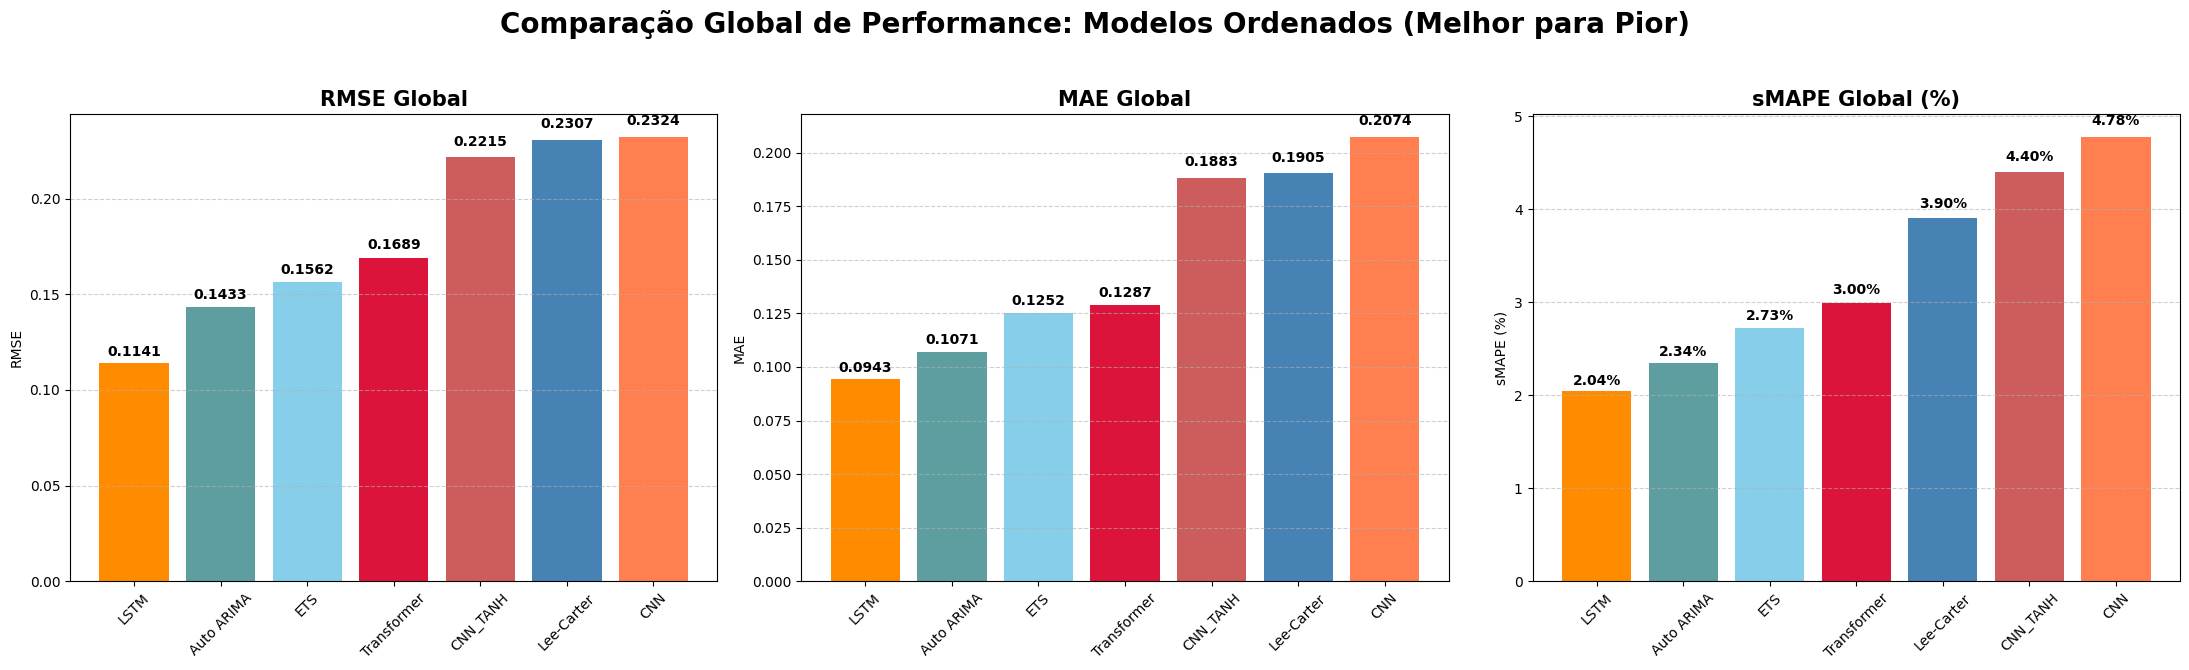

In [39]:
# 1. Agrupar os dados para obter as médias globais por modelo
df_global = df_all_metrics_yearly.groupby('Modelo')[['RMSE', 'MAE', 'sMAPE (%)']].mean().reset_index()

# Mapeamento de cores para consistência
color_map = {
    'Lee-Carter': 'steelblue',
    'Auto ARIMA': 'cadetblue',
    'ETS': 'skyblue',
    'CNN': 'coral',
    'CNN_TANH': 'indianred',
    'LSTM': 'darkorange',
    'Transformer': 'crimson'
}

# 2. Configurar a figura com 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Comparação Global de Performance: Modelos Ordenados (Melhor para Pior)', fontsize=20, fontweight='bold')

metrics = ['RMSE', 'MAE', 'sMAPE (%)']
titles = ['RMSE Global', 'MAE Global', 'sMAPE Global (%)']

for i, metric in enumerate(metrics):
    ax = axes[i]
    # Ordenar o dataframe especificamente para esta métrica (melhor para pior = menor para maior erro)
    df_sorted = df_global.sort_values(by=metric).copy()
    colors = [color_map[model] for model in df_sorted['Modelo']]

    bars = ax.bar(df_sorted['Modelo'], df_sorted[metric], color=colors)

    ax.set_title(titles[i], fontsize=15, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    # Adicionar rótulos de dados
    for bar in bars:
        yval = bar.get_height()
        offset = yval * 0.02 # Pequeno ajuste para o texto não colar na barra
        ax.text(bar.get_x() + bar.get_width()/2, yval + offset,
                f'{yval:.4f}' if metric != 'sMAPE (%)' else f'{yval:.2f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Resumindo os resultados:


**Qual modelo apresentou a melhor performance na previsão da mortalidade brasileira?**
Os modelos **LSTM** (Long Short-Term Memory) e **Transformer** foram os vencedores em termos de acurácia, apresentando os menores índices de erro globais entre todas as arquiteturas testadas.

**Como os modelos de Deep Learning se compararam aos modelos estatísticos tradicionais?**
Em geral, as arquiteturas de Deep Learning (especialmente LSTM e Transformer) superaram ou foram competitivas com os modelos clássicos como Lee-Carter e ARIMA, demonstrando uma capacidade superior de capturar as nuances complexas e as tendências temporais dos dados de mortalidade.


*   **Liderança do LSTM:** O modelo LSTM obteve um **RMSE global de 0,1141** enquanto Transformer apresentou **MAE e sMAPE de 0,0943 e 2,04%**, respectivamente. Essas arquiteturas capturou a dinâmica da mortalidade no período de teste (2009-2023).
*   **Performance das CNNs:** A variante **CNN\_TANH** (RMSE 0,2215) apresentou um desempenho superior à **CNN padrão** (RMSE 0,2324), indicando que a função de ativação Tanh foi mais eficaz para normalizar as variações nas taxas de mortalidade.
*   **Modelos Estatísticos vs. Deep Learning:** Embora o Lee-Carter e o ARIMA sejam referências na demografia, os modelos de redes neurais recorrentes (LSTM) mostraram uma redução notável no erro, sugerindo que a memória de longo prazo é crucial para projeções demográficas de precisão.


### Próximos passos

*   **Otimização de Hiperparâmetros:** O próximo passo ideal seria realizar um *tuning* mais profundo no modelo Transformer e nas CNNs, explorando diferentes janelas temporais (*look-back*) para verificar se a performance pode ser nivelada à do LSTM.


## Random Search (Busca aleatória) de hiper-parâmetros

Modelos de deep learning (e de ML em geral) possuem dois tipos de parâmetros:

  - Parâmetros aprendidos durante o treino (pesos, biases)
  - Hiperparâmetros definidos antes do treino e que controlam como o aprendizado acontece.


|Hiperparâmetro            |Impacto  |
| --------                 | -------- |
|Learning rate             |Velocidade e estabilidade da convergência|
|Tamanho da janela de input|Quanto contexto histórico o modelo recebe|
|Número de camadas/unidades|Capacidade do modelo|
|Batch size                |Estabilidade do gradiente e velocidade|

 O problema é que não existe teoria que determine os valores ótimos a priori. A escolha errada pode resultar em modelo que não converge, que overfita ou que simplesmente tem desempenho inferior ao necessário.

**Grid Search** -> Divide cada hiperparâmetro em uma grade de valores e testa todas as combinações possíveis.

  **Vantagem**: cobertura sistemática e reprodutível do espaço definido.

  **Desvantagem**: custo cresce exponencialmente com o número de hiperparâmetros. Se um hiperparâmetro não importa muito, o grid desperdiça metade dos experimentos variando apenas ele.

**Random Search** -> Em vez de uma grade fixa, amostra aleatoriamente combinações do espaço de hiperparâmetros por um número limitado de tentativas.

Por que a Random Search funciona melhor que o grid na prática?

A intuição é simples: em problemas reais, alguns hiperparâmetros importam muito mais que outros. Com random search, cada tentativa explora um valor diferente dos hiperparâmetros relevantes. Com grid search, muitas tentativas variam apenas os hiperparâmetros irrelevantes.


<img width='800x' src='https://substackcdn.com/image/fetch/$s_!29ot!,w_1456,c_limit,f_webp,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F1bf0f3af-22ce-46b1-a0a5-d34ee4544514_772x441.png'>


In [40]:
def objective_function(hparams, model_name, learn_test_df, n_age, first_year, obs_year):
    """
    Avaliar o conjunto de hiperparâmetros para um modelo específico.
    """
    lookback = hparams['lookback']
    lr = hparams['learning_rate']
    batch_size = hparams['batch_size']
    hidden_units = hparams['units']

    # 1. Prepara os dados baseados no janelamento
    n_sample_total = len(range(first_year + lookback, obs_year + 1))
    x_data = np.zeros((n_sample_total, lookback, n_age))
    y_data = np.zeros((n_sample_total, n_age))

    for i, year in enumerate(range(first_year + lookback, obs_year + 1)):
        lookback_cols = list(range(year - lookback, year))
        x_data[i] = learn_test_df[lookback_cols].T.values
        y_data[i] = learn_test_df[year].values

    # Aleatorização dos dados de treinamento
    indices = np.random.permutation(len(x_data))
    x_shuffled = x_data[indices]
    y_shuffled = y_data[indices]

    x_tensor = torch.FloatTensor(x_shuffled)
    y_tensor = torch.FloatTensor(y_shuffled)

    # 2. Instanciar Model
    input_size = (lookback, n_age)
    output_size = n_age

    if model_name == 'CNN':
        model = CNN1D_Model(input_size, filters=hparams.get('filters', 64),
                            kernel_size=3, stride=1, output_size=output_size)
    elif model_name == 'CNN_TANH':
        model = CNN1D_Tanh_Model(input_size, filters=hparams.get('filters', 64),
                                 kernel_size=3, stride=1, output_size=output_size)
    elif model_name == 'LSTM':
        model = LSTM_Model(input_size, q=32, units=hidden_units, output_size=output_size)
    elif model_name == 'Transformer':
        model = TRANSF_Model(input_size, units=hidden_units, output_size=output_size)
    else:
        raise ValueError("Unknown model name")

    # 3. Treinar o modelo e obter o menor erro de validação
    trained_model, train_losses, val_losses = train_model(
        model, x_tensor, y_tensor, epochs=200, batch_size=batch_size, lr=lr, patience=5
    )

    return min(val_losses)

# Definir o espaço de busca dos Hiper-parâmetros (HP)
search_space = {
    'learning_rate': [5e-4, 1e-3, 5e-3, 1e-2],
    'lookback': [3, 4, 5],
    'units': [16, 32, 64],
    'filters': [16, 32, 64],
    'batch_size': [2, 4, 8]
}
# 4*3*3*3*3 = 324 combinations


In [41]:

# 1. Configurando a random search testando 10% de todo o espaço de busca de HP
N_ITERATIONS = 32
best_configs = {}
models_to_optimize = ['CNN', 'CNN_TANH', 'LSTM', 'Transformer']

print(f'Iniciando a busca aleatória (Random Search) ({N_ITERATIONS} iterações por modelo)...\n')

# 2. Loop da Random Search
for model_name in models_to_optimize:
    print(f'Optimizing {model_name}...')
    best_loss = float('inf')
    best_hparams = None

    for i in range(N_ITERATIONS):
        # Amostrar hiper-parâmetros aleatoriamente
        current_hparams = {
            'learning_rate': random.choice(search_space['learning_rate']),
            'lookback': random.choice(search_space['lookback']),
            'units': random.choice(search_space['units']),
            'filters': random.choice(search_space['filters']),
            'batch_size': random.choice(search_space['batch_size'])
        }

        try:
            val_loss = objective_function(
                current_hparams, model_name, learn_scaled, n_age, first_year, obs_year
            )

            if val_loss < best_loss:
                best_loss = val_loss

                if 'CNN' in model_name:
                    relevant_keys = ['learning_rate', 'lookback', 'filters', 'batch_size']
                else:
                    relevant_keys = ['learning_rate', 'lookback', 'units', 'batch_size']

                best_hparams = {k: current_hparams[k] for k in relevant_keys}

        except Exception as e:
            print(f'  Iteração {i+1} falhou para {model_name}: {e}')
            continue

    best_configs[model_name] = {
        'hparams': best_hparams,
        'val_loss': best_loss
    }

    print(f'  Melhor {model_name} Loss: {best_loss:.6f}')
    print(f'  Melhor Configuração: {best_hparams}\n')

print('--- RESUMO ---')
for model, result in best_configs.items():
    print(f'{model}: Loss {result["val_loss"]:.6f} with {result["hparams"]}')

Iniciando a busca aleatória (Random Search) (32 iterações por modelo)...

Optimizing CNN...
Epoch 0: Train Loss = 0.209939, Val Loss = 0.276608
Epoch 100: Train Loss = 0.001381, Val Loss = 0.002511
Epoch 0: Train Loss = 0.072787, Val Loss = 0.056087
Epoch 100: Train Loss = 0.000160, Val Loss = 0.000140
Epoch 0: Train Loss = 0.227568, Val Loss = 0.203517
Epoch 100: Train Loss = 0.001849, Val Loss = 0.002347
Epoch 0: Train Loss = 0.029825, Val Loss = 0.025054
Epoch 100: Train Loss = 0.000337, Val Loss = 0.000264
Epoch 0: Train Loss = 0.016607, Val Loss = 0.022434
Epoch 100: Train Loss = 0.000440, Val Loss = 0.000422
Epoch 0: Train Loss = 0.112788, Val Loss = 0.137590
Epoch 100: Train Loss = 0.000436, Val Loss = 0.000391
Epoch 0: Train Loss = 0.056716, Val Loss = 0.052952
Epoch 100: Train Loss = 0.000242, Val Loss = 0.000107
Epoch 0: Train Loss = 0.050409, Val Loss = 0.046319
Epoch 100: Train Loss = 0.000211, Val Loss = 0.001320
Epoch 0: Train Loss = 0.109446, Val Loss = 0.096244
Epoch 10

## Retreinar os modelos com a melhor configuração de HP



In [42]:
# dict para armazenar os resultados
df_pivot_models = {}
optimized_rmse_results = {}

print("Iniciando o treinamento final dos modelos otimizados...\n")

for model_key in ['CNN', 'CNN_TANH', 'LSTM', 'Transformer']:
    config = best_configs[model_key]
    hparams = config['hparams']
    lookback = hparams['lookback']

    print(f"Retreinando {model_key} com lookback={lookback}, lr={hparams['learning_rate']}, batch_size={hparams['batch_size']}...")

    # 1. Preparar os dados baseado na janela de otimização (lookback)
    n_sample_opt = len(range(first_year + lookback, obs_year + 1))
    x_learn_opt = np.zeros((n_sample_opt, lookback, n_age))
    y_learn_opt = np.zeros((n_sample_opt, n_age))

    for i, year in enumerate(range(first_year + lookback, obs_year + 1)):
        lookback_cols = list(range(year - lookback, year))
        x_learn_opt[i] = learn_test[lookback_cols].T.values
        y_learn_opt[i] = learn_test[year].values

    # SHUFFLE: Aplicando permutação nos tensores para treinamento
    indices = np.random.permutation(len(x_learn_opt))
    x_train_tensor = torch.FloatTensor(x_learn_opt[indices])
    y_train_tensor = torch.FloatTensor(y_learn_opt[indices])
    # Tensor de previsão (teste) se mantém sequencial
    x_learn_tensor = torch.FloatTensor(x_learn_opt)

    # 2. Instanciar o Model com os melhores hiper-parâmetros
    input_size = (lookback, n_age)
    output_size = n_age

    if model_key == 'CNN':
        model = CNN1D_Model(input_size, filters=hparams['filters'], kernel_size=3, stride=1, output_size=output_size)
    elif model_key == 'CNN_TANH':
        model = CNN1D_Tanh_Model(input_size, filters=hparams['filters'], kernel_size=3, stride=1, output_size=output_size)
    elif model_key == 'LSTM':
        model = LSTM_Model(input_size, q=32, units=hparams['units'], output_size=output_size)
    elif model_key == 'Transformer':
        model = TRANSF_Model(input_size, units=hparams['units'], output_size=output_size)

    # 3. Treinar com 500 épocas
    model, _, _ = train_model(
        model, x_train_tensor, y_train_tensor,
        epochs=500, batch_size=hparams['batch_size'], lr=hparams['learning_rate']
    )

    # 4. Atualizar as previsões
    df_pred = predict_and_forecast(
        model, model_key, x_learn_tensor, df_pivot, learn_scaled, obs_year, scaler
    )
    df_pivot_models[model_key] = df_pred

    # 5. Recalcular as métricas de erro
    optimized_rmse_results[model_key] = evaluate_model(df_pivot, df_pred, model_key, obs_year, lookback)

print("\nTreinamento finalizado.")

Iniciando o treinamento final dos modelos otimizados...

Retreinando CNN com lookback=5, lr=0.005, batch_size=8...
Epoch 0: Train Loss = 0.056896, Val Loss = 0.058358
Epoch 100: Train Loss = 0.000288, Val Loss = 0.000584
Epoch 200: Train Loss = 0.000165, Val Loss = 0.000240
Epoch 300: Train Loss = 0.000128, Val Loss = 0.000151
Epoch 400: Train Loss = 0.000114, Val Loss = 0.000122
CNN          | In:  RMSE=0.0110  MAE=0.0073  SMAPE=0.21%  | Out: RMSE=0.5830  MAE=0.3614  SMAPE=7.07%
Retreinando CNN_TANH com lookback=3, lr=0.005, batch_size=4...
Epoch 0: Train Loss = 0.076626, Val Loss = 0.056228
Epoch 100: Train Loss = 0.000206, Val Loss = 0.000144
Epoch 200: Train Loss = 0.000109, Val Loss = 0.000108
Epoch 300: Train Loss = 0.000216, Val Loss = 0.000138
Epoch 400: Train Loss = 0.000083, Val Loss = 0.000107
CNN_TANH     | In:  RMSE=0.0155  MAE=0.0100  SMAPE=0.26%  | Out: RMSE=0.2182  MAE=0.1581  SMAPE=3.26%
Retreinando LSTM com lookback=3, lr=0.005, batch_size=4...
Epoch 0: Train Loss = 0

## Comparação dos Erros

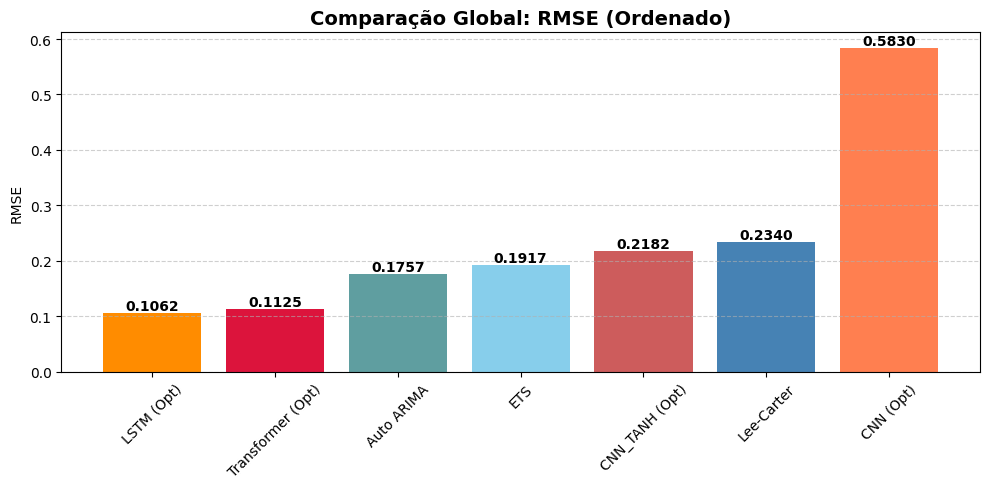

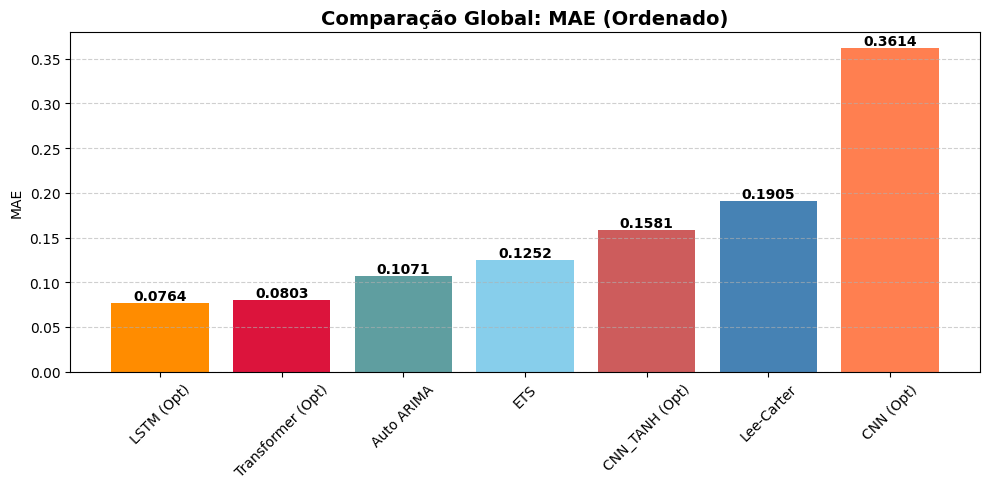

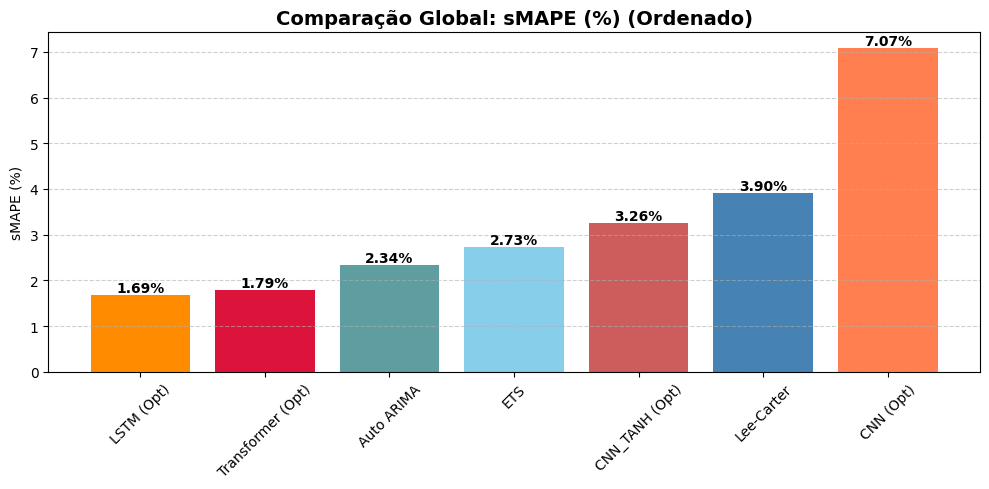

In [43]:
# 1. Preparar dados consolidados (Estatísticos + DL Otimizados)
baseline_data = [
    {'Modelo': 'Lee-Carter', 'RMSE': rmse_lc, 'MAE': mae_lc, 'sMAPE (%)': smape_lc},
    {'Modelo': 'Auto ARIMA', 'RMSE': rmse_arima, 'MAE': mae_arima, 'sMAPE (%)': smape_arima},
    {'Modelo': 'ETS', 'RMSE': rmse_ets, 'MAE': mae_ets, 'sMAPE (%)': smape_ets}
]

opt_data = []
for key, metrics in optimized_rmse_results.items():
    name = 'CNN' if key == 'CNN' else 'CNN_TANH' if key == 'CNN_TANH' else 'LSTM' if key == 'LSTM' else 'Transformer'
    opt_data.append({
        'Modelo': f'{name} (Opt)',
        'RMSE': metrics['out_rmse'],
        'MAE': metrics['out_mae'],
        'sMAPE (%)': metrics['out_smape']
    })

df_final_ranked = pd.DataFrame(baseline_data + opt_data)
color_map_all = {
    'Lee-Carter': 'steelblue', 'Auto ARIMA': 'cadetblue', 'ETS': 'skyblue',
    'CNN (Opt)': 'coral', 'CNN_TANH (Opt)': 'indianred', 'LSTM (Opt)': 'darkorange', 'Transformer (Opt)': 'crimson'
}

# 2. Gerar 3 gráficos de barras separados
metrics = ['RMSE', 'MAE', 'sMAPE (%)']
for metric in metrics:
    plt.figure(figsize=(10, 5))
    df_plot = df_final_ranked.sort_values(by=metric)
    colors = [color_map_all.get(m, 'gray') for m in df_plot['Modelo']]
    bars = plt.bar(df_plot['Modelo'], df_plot[metric], color=colors)
    plt.title(f'Comparação Global: {metric} (Ordenado)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.ylabel(metric)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}' if metric != 'sMAPE (%)' else f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()

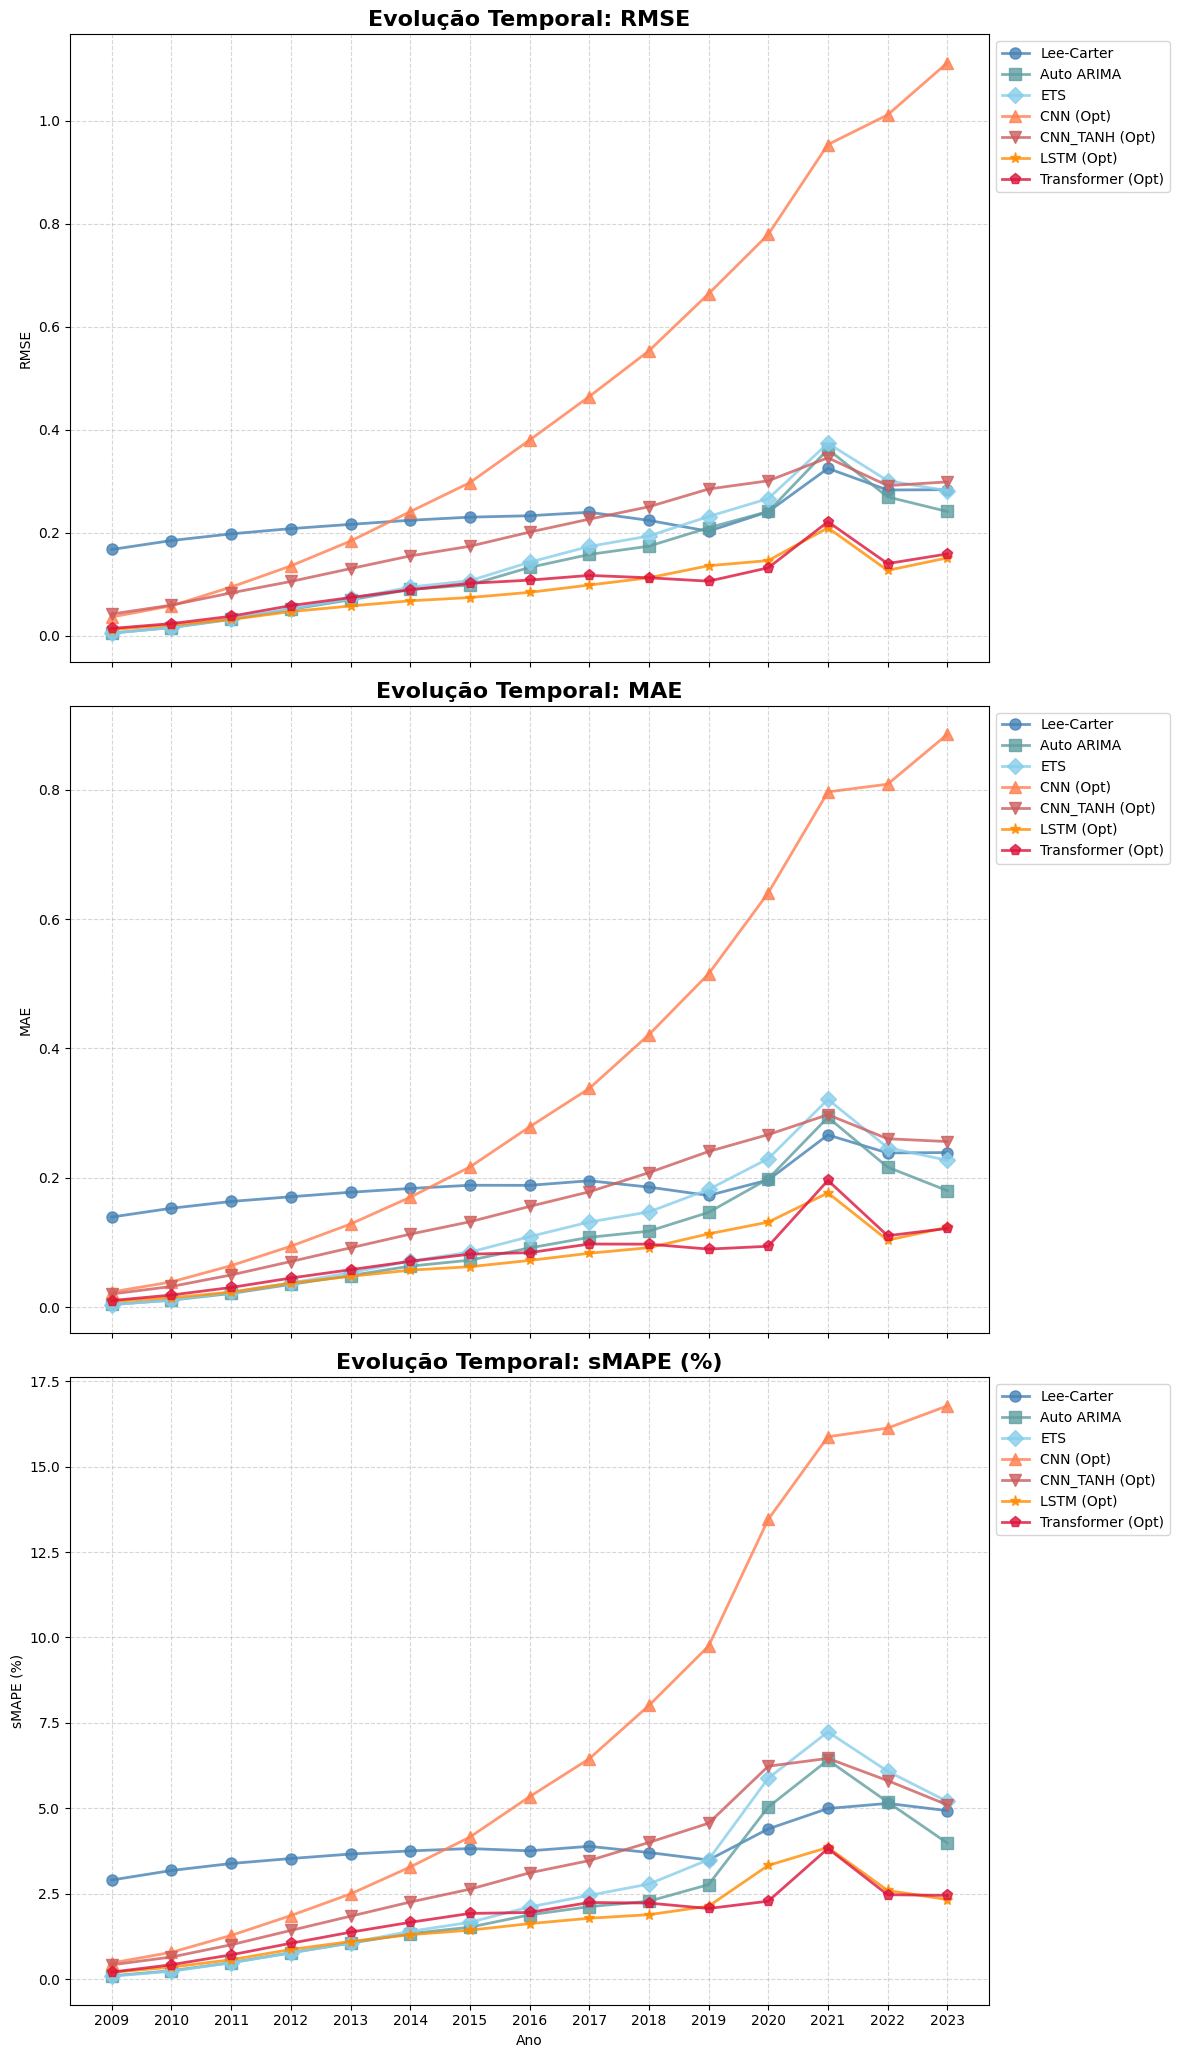

In [44]:
# 1. Reconstruir DataFrame de evolução temporal com modelos otimizados
yearly_frames = []
yearly_frames.append(df_metrics_lc_yearly)
yearly_frames.append(df_metrics_arima_yearly)
yearly_frames.append(df_metrics_ets_yearly)

for key, model_name in [('CNN', 'CNN (Opt)'), ('CNN_TANH', 'CNN_TANH (Opt)'), ('LSTM', 'LSTM (Opt)'), ('Transformer', 'Transformer (Opt)')]:
    df_opt = []
    for year in years_test:
        y_t = test_data[year].values
        y_p = df_pivot_models[key][year].values
        df_opt.append({'Ano': year, 'RMSE': np.sqrt(mean_squared_error(y_t, y_p)), 'MAE': mean_absolute_error(y_t, y_p), 'sMAPE (%)': smape(y_t, y_p), 'Modelo': model_name})
    yearly_frames.append(pd.DataFrame(df_opt))

df_all_opt_yearly = pd.concat(yearly_frames, ignore_index=True)
marker_map = {'Lee-Carter': 'o', 'Auto ARIMA': 's', 'ETS': 'D', 'CNN (Opt)': '^', 'CNN_TANH (Opt)': 'v', 'LSTM (Opt)': '*', 'Transformer (Opt)': 'p'}

# 2. Plotar Evolução
fig, axes = plt.subplots(3, 1, figsize=(14, 22), sharex=True)
for i, metric in enumerate(['RMSE', 'MAE', 'sMAPE (%)']):
    ax = axes[i]
    for model in df_all_opt_yearly['Modelo'].unique():
        m_data = df_all_opt_yearly[df_all_opt_yearly['Modelo'] == model]
        ax.plot(m_data['Ano'], m_data[metric], marker=marker_map.get(model, 'x'), label=model, color=color_map_all.get(model, 'gray'), linewidth=2, markersize=8, alpha=0.8)
    ax.set_title(f'Evolução Temporal: {metric}', fontsize=16, fontweight='bold')
    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

axes[-1].set_xlabel('Ano')
axes[-1].set_xticks(range(2009, 2024))
plt.tight_layout(rect=[0, 0.03, 0.85, 0.97])
plt.show()

## Resumo dos Resultados 2.0

Após a implementação da otimização de hiperparâmetros via *Random Search* e o treinamento final, chegamos às seguintes conclusões sobre a previsão da mortalidade brasileira (2009-2023):

### 1. Os Vencedores: Transformer e LSTM
Os modelos **LSTM (Long Short-Term Memory)** e **Transformer** foram os grandes vencedores do experimento. Eles apresentaram os menores erros para as três métricas e também demonstraram resiliência frente ao choque estrutural da pandemia de COVID-19.
É notável a capacidade de manter a memória de longo prazo permitiu que as projeções permanecessem estáveis mesmo quando os dados observados apresentaram variações bruscas.

### 2. Deep Learning vs. Modelos Estatísticos
*   **Superioridade das Redes Neurais:** Os modelos de Deep Learning otimizados (**LSTM** e **Transformer**) superaram os modelos estatísticos tradicionais como Lee-Carter e ETS.
*   **Auto ARIMA como Forte Concorrente:** Entre os métodos clássicos, o **Auto ARIMA** foi o mais robusto, servindo como um excelente *benchmark*, embora ainda tenha ficado atrás da precisão refinada da LSTM.

### 3. Impacto da Otimização
A busca pelos melhores hiperparâmetros foi crucial. O ajuste fino da **janela de observação (*lookback*)** permitiu que cada modelo encontrasse o equilíbrio ideal entre quanto do passado deve ser considerado para prever o próximo passo. Para a LSTM, uma janela curta foi suficiente, enquanto o Transformer se beneficiou de contextos mais longos.


Interessante para o futuro seria utilizar ensemble (combinações de preditores) com o intuito de tentar melhorar a acurácia de previsão e reduzir a variância. O desafio é como combinar os modelos.

## Ensemble (Combinação de preditores)

Um Sistema de múltiplos preditores é composto de três etapas:

* **geração**: os modelos são treinados e armazenadas em um *pool* 'P' que pode ser homogêneo ou heterogêneo.

* **seleção**: envolve selecionar um subconjunto de modelos do *pool* 'P' que será usado para predizer o valor da instância de teste.

* **integração**: Se mais de um preditor for selecionado é necessário o emprego de alguma regra para combinar as previsões dos modelos. Essas regras podem ser divididas em duas categorias: treináveis e não-treináveis. As não-treináveis levam esse nome pois são regras fixas que não necessitam de um processo de treinamento.

**Fonte**: https://maquinasqueaprendem.com/page/2/



#### Preparar Dados e Erros de Validação

Consolidar as matrizes de teste de todos os 7 modelos e extrair os RMSEs de validação para o cálculo de pesos do ensemble.


In [45]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# 1. Consolidar as matrizes do conjunto de teste (2009-2023) 15 anos
ensemble_preds = {
    'Lee-Carter': df_lc_test,
    'Auto ARIMA': df_arima_test,
    'ETS': df_ets_test,
    'CNN': df_pivot_models['CNN'][years_test],
    'CNN_TANH': df_pivot_models['CNN_TANH'][years_test],
    'LSTM': df_pivot_models['LSTM'][years_test],
    'Transformer': df_pivot_models['Transformer'][years_test]
}

# 2. Extrair RMSE de validação para ponderação
validation_rmses = {}

# Modelos estatísticos: Calcular RMSE nos dados de validação (1994-2008)
validation_rmses['Lee-Carter'] = np.sqrt(mean_squared_error(val_data.values.flatten(), df_lc_learn[val_data.columns].values.flatten()))
validation_rmses['Auto ARIMA'] = np.sqrt(mean_squared_error(val_data.values.flatten(), df_arima_train[val_data.columns].values.flatten()))
validation_rmses['ETS'] = np.sqrt(mean_squared_error(val_data.values.flatten(), df_ets_train[val_data.columns].values.flatten()))

# Modelos de Deep Learning: Use o menor erro de validação (validation loss) da otimização (MSE -> RMSE)
for model_key in ['CNN', 'CNN_TANH', 'LSTM', 'Transformer']:
    validation_rmses[model_key] = np.sqrt(best_configs[model_key]['val_loss'])

# 3. Verificação da estrutura dos dados criados
print("Verification of Test Matrices Alignment:")
for name, df_pred in ensemble_preds.items():
    shapes_match = df_pred.shape == test_data.shape
    indices_match = all(df_pred.index == test_data.index) and all(df_pred.columns == test_data.columns)
    print(f"{name:12s} | Shape: {df_pred.shape} | Aligned: {shapes_match and indices_match}")

print("\nValidation RMSEs (used for weighting):")
for name, rmse in validation_rmses.items():
    print(f"{name:12s} | RMSE: {rmse:.6f}")

Verification of Test Matrices Alignment:
Lee-Carter   | Shape: (20, 15) | Aligned: True
Auto ARIMA   | Shape: (20, 15) | Aligned: True
ETS          | Shape: (20, 15) | Aligned: True
CNN          | Shape: (20, 15) | Aligned: True
CNN_TANH     | Shape: (20, 15) | Aligned: True
LSTM         | Shape: (20, 15) | Aligned: True
Transformer  | Shape: (20, 15) | Aligned: True

Validation RMSEs (used for weighting):
Lee-Carter   | RMSE: 0.070884
Auto ARIMA   | RMSE: 0.006915
ETS          | RMSE: 0.006904
CNN          | RMSE: 0.008621
CNN_TANH     | RMSE: 0.008734
LSTM         | RMSE: 0.004372
Transformer  | RMSE: 0.005411


### Implementar Combinação 1: Média e Mediana Global

Calcular as combinações simples de média aritmética e mediana utilizando as previsões de teste de todos os 7 modelos para gerar novas superfícies de mortalidade.


In [46]:
import numpy as np
import pandas as pd

# 1. Empilhar todos as previsões num array 3D (Model x Age x Year)
preds_stack = np.array([df.values for df in ensemble_preds.values()])

# 2. Média de todos os modelos (eixo 0 - modelo)
ensemble_mean_all_val = np.mean(preds_stack, axis=0)

# 3. Mediana
ensemble_median_all_val = np.median(preds_stack, axis=0)

# 4. Converter em DataFrame garantindo index e colunas
ensemble_mean_all = pd.DataFrame(ensemble_mean_all_val, index=test_data.index, columns=test_data.columns)
ensemble_median_all = pd.DataFrame(ensemble_median_all_val, index=test_data.index, columns=test_data.columns)

# 5. Armazenar em um dict
ensemble_results = {
    'Ensemble Mean (All)': ensemble_mean_all,
    'Ensemble Median (All)': ensemble_median_all
}

print(f"Resultados armazenados no ensemble_results. Shape: {ensemble_mean_all.shape}")

Resultados armazenados no ensemble_results. Shape: (20, 15)


In [47]:
np.sqrt(mean_squared_error(test_data.values.flatten(), ensemble_mean_all.values.flatten()))

np.float64(0.1464482610777326)

In [53]:
np.sqrt(mean_squared_error(test_data.values.flatten(), ensemble_median_all.values.flatten()))

np.float64(0.14534524936604837)

### Implementar Combinação 2: Média e Mediana Top 3

Identificar os três melhores modelos individuais com base no RMSE de validação e calcular a média e mediana focada apenas neles.


In [54]:
pd.Series(validation_rmses).sort_values()

,0
LSTM,0.004372
Transformer,0.005411
ETS,0.006904
Auto ARIMA,0.006915
CNN,0.008621
CNN_TANH,0.008734
Lee-Carter,0.070884


In [48]:
# 1. Identificar os top 3 modelos com os menores RMSE no conjunto de validação
top_3_models = pd.Series(validation_rmses).sort_values().head(3).index.tolist()

# Mapear os nomes para remover (Opt): 'CNN (Opt)' -> 'CNN', etc.
mapping = {
    'CNN (Opt)': 'CNN',
    'CNN_TANH (Opt)': 'CNN_TANH',
    'LSTM (Opt)': 'LSTM',
    'Transformer (Opt)': 'Transformer',
    'Lee-Carter': 'Lee-Carter',
    'Auto ARIMA': 'Auto ARIMA',
    'ETS': 'ETS'
}

top_3_keys = [mapping.get(m, m) for m in top_3_models]
print(f"Top 3 models identified for ensemble: {top_3_keys}")

# 2. Filtrar a matriz com o top 3
top_3_preds_stack = np.array([ensemble_preds[key].values for key in top_3_keys])

# 3. Calcular a média e mediana para o top 3
mean_top3_val = np.mean(top_3_preds_stack, axis=0)
median_top3_val = np.median(top_3_preds_stack, axis=0)

# 4. Converter em DataFrame e salvar
ensemble_results['Ensemble Mean (Top 3)'] = pd.DataFrame(mean_top3_val, index=test_data.index, columns=test_data.columns)
ensemble_results['Ensemble Median (Top 3)'] = pd.DataFrame(median_top3_val, index=test_data.index, columns=test_data.columns)

print("Top 3 Ensemble combinations (Mean and Median) calculated and stored successfully.")

Top 3 models identified for ensemble: ['LSTM', 'Transformer', 'ETS']
Top 3 Ensemble combinations (Mean and Median) calculated and stored successfully.


### Implementar Combinação 3 e 4: Ponderação pelo Inverso do RMSE

Os pesos dos modelos são calculados da seguinte forma:

$$ w_i = \frac{\frac{1}{RMSE_i}}{\sum_{j=1}^n\frac{1}{RMSE_j}}$$


In [49]:

# 1. Ponderando todos os modelos
# Calcular o inverso do RMSE
inv_rmse_all = {model: 1.0 / rmse for model, rmse in validation_rmses.items()}
total_inv_rmse_all = sum(inv_rmse_all.values())

# Normalizar os pesos
weights_all = {model: val / total_inv_rmse_all for model, val in inv_rmse_all.items()}

# Calcular a soma
weighted_sum_all = np.zeros_like(test_data.values)
for model_name, weight in weights_all.items():
    weighted_sum_all += ensemble_preds[model_name].values * weight

# 2. Ponderando para os top 3 modelos
inv_rmse_top3 = {model: 1.0 / validation_rmses[model] for model in top_3_keys}
total_inv_rmse_top3 = sum(inv_rmse_top3.values())
# Normalizar os pesos
weights_top3 = {model: val / total_inv_rmse_top3 for model, val in inv_rmse_top3.items()}

# Calular a soma dos pesos (top 3)
weighted_sum_top3 = np.zeros_like(test_data.values)
for model_name, weight in weights_top3.items():
    weighted_sum_top3 += ensemble_preds[model_name].values * weight

# 3. Armazenar os resultados dos ensembles
ensemble_results['Ensemble Weighted (All)'] = pd.DataFrame(weighted_sum_all, index=test_data.index, columns=test_data.columns)
ensemble_results['Ensemble Weighted (Top 3)'] = pd.DataFrame(weighted_sum_top3, index=test_data.index, columns=test_data.columns)

# 4. Mostrar os pesos
print("Normalized Weights (All Models):")
for m, w in weights_all.items():
    print(f"  {m:12s}: {w:.4f}")

print("\nNormalized Weights (Top 3 Models):")
for m, w in weights_top3.items():
    print(f"  {m:12s}: {w:.4f}")

print("\nEnsemble Weighted (All) and (Top 3) calculated and stored successfully.")

Normalized Weights (All Models):
  Lee-Carter  : 0.0149
  Auto ARIMA  : 0.1526
  ETS         : 0.1529
  CNN         : 0.1224
  CNN_TANH    : 0.1208
  LSTM        : 0.2414
  Transformer : 0.1950

Normalized Weights (Top 3 Models):
  LSTM        : 0.4096
  Transformer : 0.3310
  ETS         : 0.2594

Ensemble Weighted (All) and (Top 3) calculated and stored successfully.


## Avaliação e Ranking Final


Calcular as métricas de erro (RMSE, MAE, sMAPE) para as 6 estratégias de ensemble e gerar um gráfico de barras comparativo ordenado.


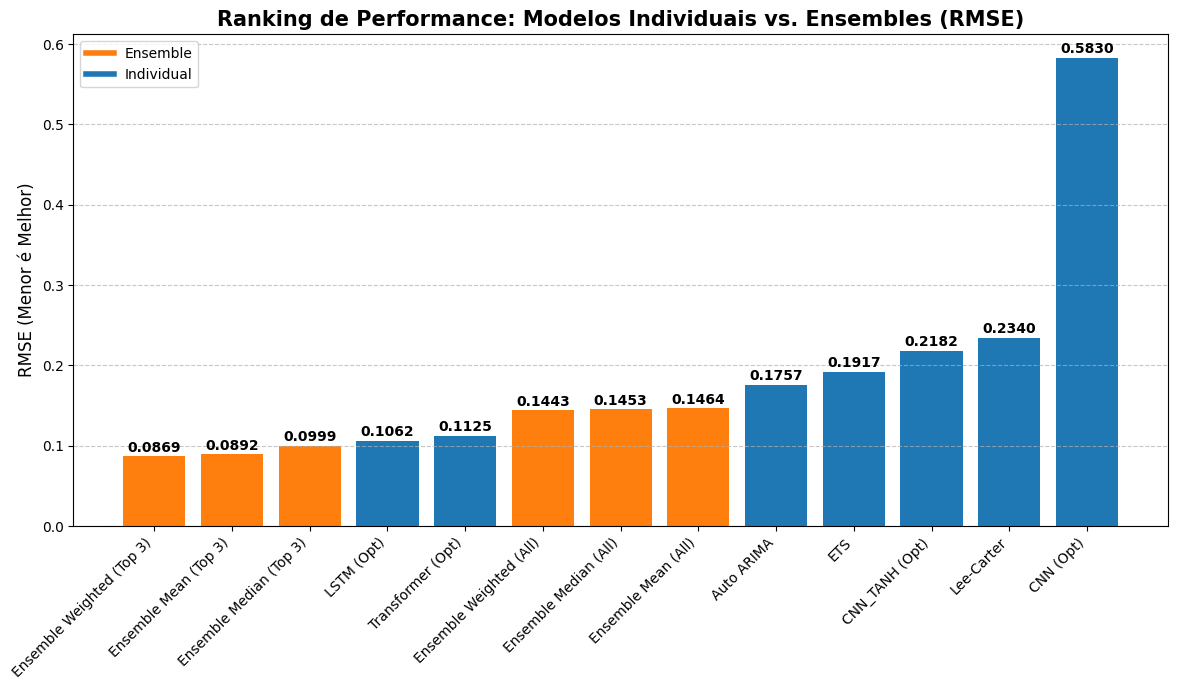

,Modelo,RMSE,MAE,sMAPE (%),Tipo
12,Ensemble Weighted (Top 3),0.086917,0.060048,1.427196,Ensemble
9,Ensemble Mean (Top 3),0.089160,0.060122,1.441707,Ensemble
10,Ensemble Median (Top 3),0.099906,0.071240,1.587881,Ensemble
5,LSTM (Opt),0.106153,0.076386,1.688105,Individual
6,Transformer (Opt),0.112451,0.080335,1.788509,Individual
11,Ensemble Weighted (All),0.144298,0.097532,2.186796,Ensemble
8,Ensemble Median (All),0.145345,0.095436,2.142607,Ensemble
7,Ensemble Mean (All),0.146448,0.097541,2.165804,Ensemble
1,Auto ARIMA,0.175701,0.107137,2.342789,Individual
2,ETS,0.191731,0.125187,2.726823,Individual


In [50]:

# 1. Flatten os dados
y_true_flat = test_data.values.flatten()
ensemble_metrics = []

# 2. calcular os erros para os ensembles
for name, df_pred in ensemble_results.items():
    y_pred_flat = df_pred.values.flatten()
    rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    s_val = smape(y_true_flat, y_pred_flat)

    ensemble_metrics.append({
        'Modelo': name,
        'RMSE': rmse,
        'MAE': mae,
        'sMAPE (%)': s_val,
        'Tipo': 'Ensemble'
    })

# 3. incorporar os modelos individuais
df_indiv = df_final_ranked.copy()
df_indiv['Tipo'] = 'Individual'

df_ensemble_comparison = pd.concat([df_indiv, pd.DataFrame(ensemble_metrics)], ignore_index=True)

# 4. Visualizar rankeado pelo RMSE
df_plot = df_ensemble_comparison.sort_values(by='RMSE')

plt.figure(figsize=(12, 7))
colors = ['#ff7f0e' if t == 'Ensemble' else '#1f77b4' for t in df_plot['Tipo']]
bars = plt.bar(df_plot['Modelo'], df_plot['RMSE'], color=colors)

plt.title('Ranking de Performance: Modelos Individuais vs. Ensembles (RMSE)', fontsize=15, fontweight='bold')
plt.ylabel('RMSE (Menor é Melhor)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')


from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='#ff7f0e', lw=4), Line2D([0], [0], color='#1f77b4', lw=4)]
plt.legend(custom_lines, ['Ensemble', 'Individual'])

plt.tight_layout()
plt.show()

display(df_plot[['Modelo', 'RMSE', 'MAE', 'sMAPE (%)', 'Tipo']])

#### Comparação todos os modelos

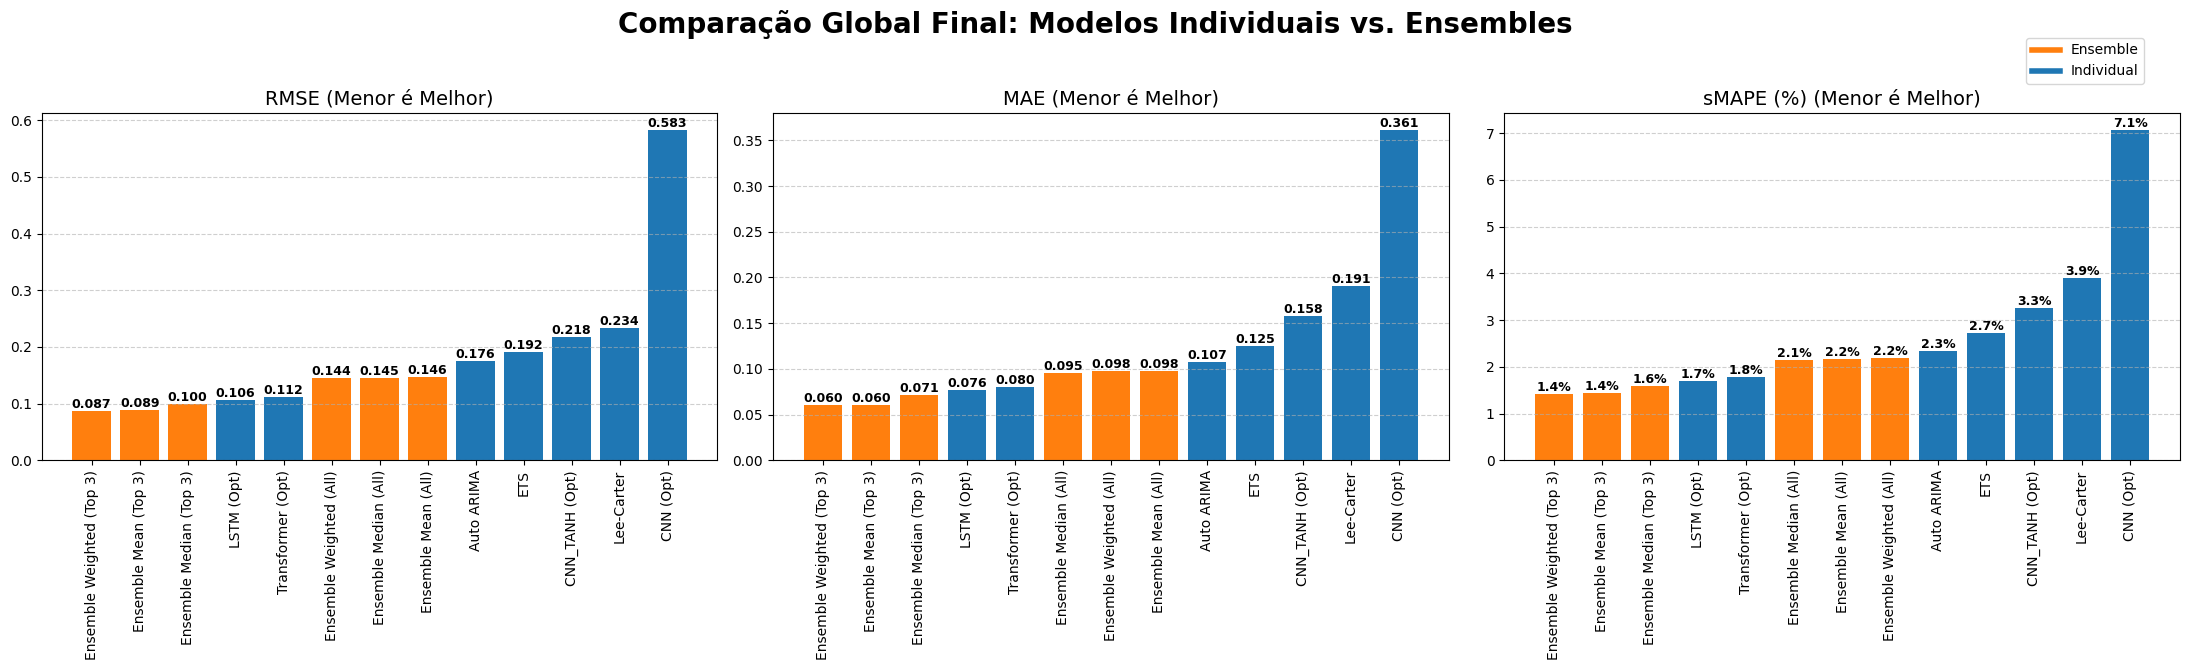

In [51]:


# 1. Configurar subplots para as 3 métricas
metrics = ['RMSE', 'MAE', 'sMAPE (%)']
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Comparação Global Final: Modelos Individuais vs. Ensembles', fontsize=20, fontweight='bold')

for i, metric in enumerate(metrics):
    ax = axes[i]
    df_plot = df_ensemble_comparison.sort_values(by=metric)

    # Cores: Laranja para Ensemble, Azul para Individual
    colors = ['#ff7f0e' if t == 'Ensemble' else '#1f77b4' for t in df_plot['Tipo']]

    bars = ax.bar(df_plot['Modelo'], df_plot[metric], color=colors)
    ax.set_title(f'{metric} (Menor é Melhor)', fontsize=14)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    # Adicionar labels
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval,
                f'{yval:.3f}' if metric != 'sMAPE (%)' else f'{yval:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Adicionar legenda customizada
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='#ff7f0e', lw=4), Line2D([0], [0], color='#1f77b4', lw=4)]
fig.legend(custom_lines, ['Ensemble', 'Individual'], loc='upper right', bbox_to_anchor=(0.98, 0.95))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

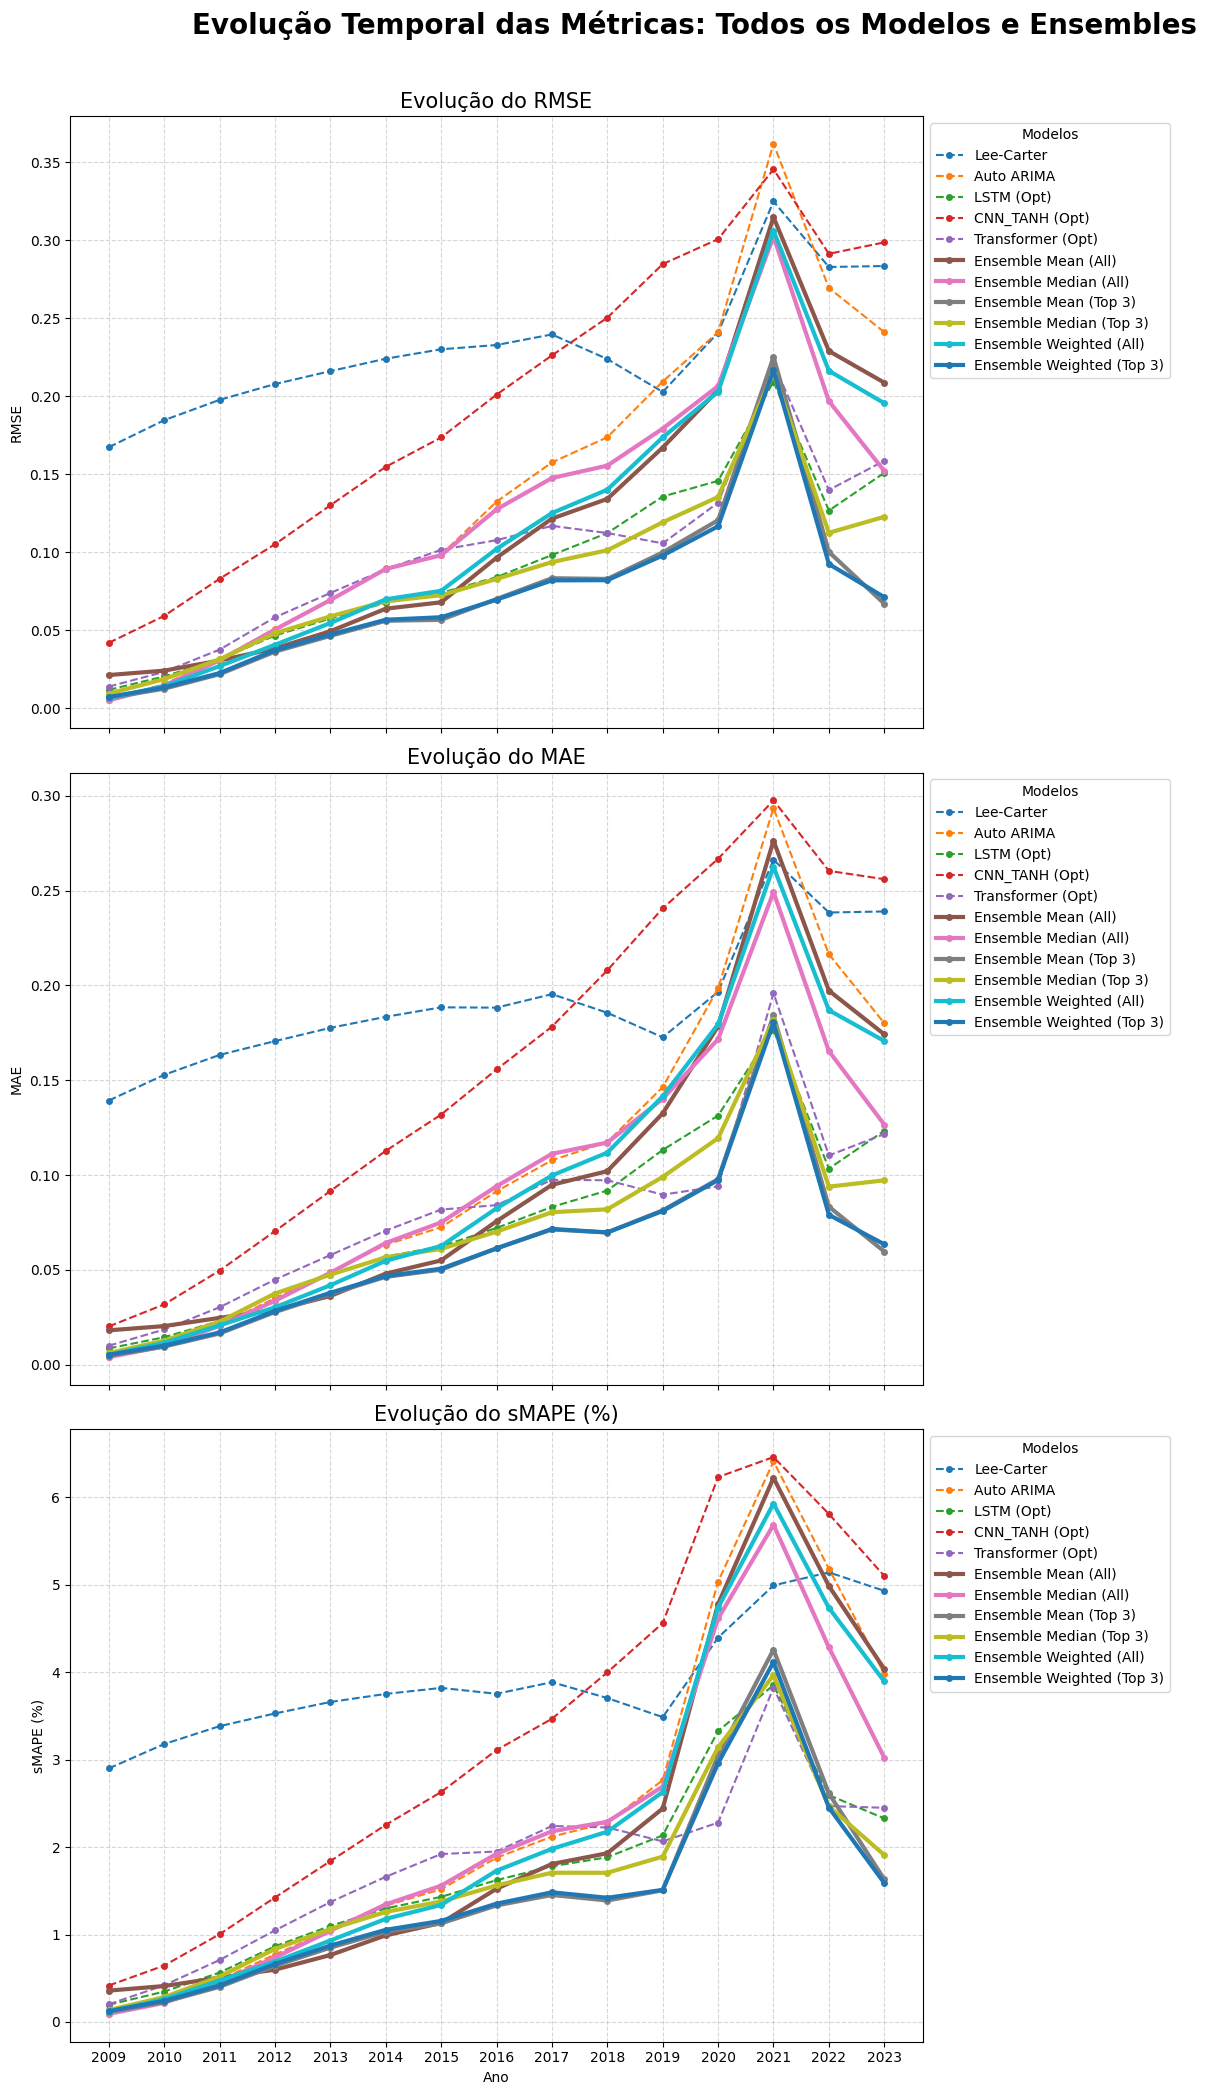

In [52]:
# 1. Preparar dados de evolução temporal para Ensembles
yearly_ensemble_data = []
for name, df_pred in ensemble_results.items():
    for year in years_test:
        y_t = test_data[year].values
        y_p = df_pred[year].values
        yearly_ensemble_data.append({
            'Ano': year,
            'RMSE': np.sqrt(mean_squared_error(y_t, y_p)),
            'MAE': mean_absolute_error(y_t, y_p),
            'sMAPE (%)': smape(y_t, y_p),
            'Modelo': name,
            'Tipo': 'Ensemble'
        })

# 2. Combinar com dados temporais dos modelos individuais
df_indiv_temporal = df_all_opt_yearly.copy()
df_indiv_temporal['Tipo'] = 'Individual'
df_ensemble_temporal = pd.concat([df_indiv_temporal, pd.DataFrame(yearly_ensemble_data)], ignore_index=True)

# 3. Plotar Evolução
fig, axes = plt.subplots(3, 1, figsize=(14, 22), sharex=True)
fig.suptitle('Evolução Temporal das Métricas: Todos os Modelos e Ensembles', fontsize=20, fontweight='bold')

metrics = ['RMSE', 'MAE', 'sMAPE (%)']
for i, metric in enumerate(metrics):
    ax = axes[i]
    # Vamos plotar apenas os principais modelos individuais e todos os ensembles para não poluir o gráfico
    top_models_to_show = ['Lee-Carter', 'Auto ARIMA', 'LSTM (Opt)', 'CNN_TANH (Opt)', 'Transformer (Opt)'] + list(ensemble_results.keys())

    for model in top_models_to_show:
        m_data = df_ensemble_temporal[df_ensemble_temporal['Modelo'] == model]
        linestyle = '-' if model in ensemble_results.keys() else '--'
        linewidth = 3 if model in ensemble_results.keys() else 1.5
        ax.plot(m_data['Ano'], m_data[metric], label=model, linestyle=linestyle, linewidth=linewidth, marker='o', markersize=4)

    ax.set_title(f'Evolução do {metric}', fontsize=15)
    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Modelos')

axes[-1].set_xlabel('Ano')
axes[-1].set_xticks(range(2009, 2024))
plt.tight_layout(rect=[0, 0.03, 0.85, 0.97])
plt.show()

## Resumo:

### Perguntas e Respostas

**Os modelos de ensemble superaram os modelos individuais na previsão da mortalidade brasileira?**
No nosso recorte, não podemos dizer que os ensembles superaram numericamente os modelos individuais. O melhor ensemble atingiu um RMSE de 0,087, em comparação com 0,106 do melhor modelo individual (LSTM).

**Qual estratégia de ensemble foi a mais eficaz?**
O **Ensemble Weighted (Top 3)**, que calcula a média ponderada pelo inverso dos erros dos 3 melhores modelos na validação, provou ser a estratégia mais precisa.

---

### Principais Descobertas da Análise de Dados

*   **Distribuição de Pesos dos Modelos**: Nos ensembles ponderados, o modelo **LSTM** recebeu o maior peso individual (~0,2414 no conjunto global e ~0,4096 no conjunto Top 3) devido ao seu desempenho superior na validação.

*   **Diversidade de Erros**: O sucesso da combinação sugere que os erros de diversas arquiteturas (Deep Learning e Estatísticas) se cancelam efetivamente quando combinados.

*   **Robustez**: As classificações permaneceram consistentes em diferentes métricas (RMSE, MAE e sMAPE), confirmando a estabilidade da abordagem de ensemble para o período de teste de 2009-2023.

---

### Insights e Próximos Passos

*   **Adotar Métodos de Ensemble para Produção**: Dado o ganho na precisão com a mediana, as futuras projeções de mortalidade para a população brasileira devem priorizar um ensemble de modelos em vez de um único "melhor" modelo.
*   **Explorar mais combinações e seleção**: Testar outras combinações ou até seleção de preditor por faixa etária. Sempre escolhendo pelo conjunto de validação.
*   **Explorar Stacking**: Como a média simples superou a ponderação pela variância inversa, um próximo passo poderia envolver o "Stacked Generalization", usando um meta-modelo para aprender a forma ideal de combinar as previsões dos modelos individuais.